# CANE — Context-Aware Notification Engine
## PPO (proximal policy optimisation)

This notebook implements the **PPO** arm of the CANE comparison.

PPO is the policy-gradient endpoint of the algorithm progression
(bandit -> DQN -> Double DQN -> PPO). Its role is the other half of **RQ2**:
LinUCB establishes that a contextual bandit, optimising only the immediate
expected reward, is not enough. PPO asks whether a method that optimises the
*discounted return* — and therefore prices a send's future fatigue and churn
risk at the moment it decides to send — closes that gap.

The distinction matters here because the cost of a notification is deferred.
A send raises fatigue, fatigue suppresses the next click and eventually risks a
terminal opt-out. A bandit cannot represent that chain: it sees fatigue in its
context but has no model of the fact that *its own action* is what produced it.
PPO propagates that consequence backwards through the value function.

**Build order**

| Section | Contents |
|---|---|
| 1 | Setup — imports, action constants (shared) |
| 2 | Agent interface (shared contract for all four algorithms) |
| 3 | Environment: config, archetype curves, `CANEEnv` (shared) |
| 4 | Baselines, harness and the evaluation protocol (shared) |
| 5 | Environment sanity checks and plotting conventions (shared) |
| 6 | PPO agent |
| 7 | Correctness tests against known ground truth |
| 8 | Registry, driver and per-archetype results |
| 9 | Training curves and optimisation diagnostics |
| 10 | Per-archetype behaviour and the decision distribution |
| 11 | Part B: hyperparameter search and robustness |
| 12 | Statistical robustness |

**Shared code is duplicated, not imported.** Sections 1-5 are copied
character-for-character from `AssignementCode(LinUCB).ipynb`. The project
convention is one self-contained notebook per algorithm, so the copy is the
interface: if the environment moves, both notebooks must be updated together.
Section 7 diffs the copy against the original mechanically rather than trusting
that it was pasted correctly.

---

## 1. Setup

Copied verbatim from the LinUCB notebook, plus `torch`. PPO is the only arm
that needs a neural network; everything above it in the progression is either
closed-form (LinUCB) or would use the same `torch` dependency (DQN).

The networks here are two small MLPs, so the run is pinned to **CPU**: the
tensors are far too small for a GPU to pay for its own kernel-launch overhead,
and CPU keeps the run reproducible and free of a CUDA dependency for teammates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from abc import ABC, abstractmethod


# --- Action space -----------------------------------------------------------
# Defined once and imported everywhere so the agents, the environment and the
# plotting code can never disagree about what "1" means.
HOLD = 0        # stay silent -> fatigue decays
ENGAGE = 1      # engagement nudge (social / community update)
INCENTIVE = 2   # incentive nudge (high-value promo reward)

N_ACTIONS = 3
ACTION_NAMES = {HOLD: "Hold", ENGAGE: "Engage", INCENTIVE: "Incentive"}


# --- Observation layout -----------------------------------------------------
# The env returns s = [hour, day, active, fatigue, recency] as a flat float32
# array. These constants are the single source of truth for the column order;
# if the env owner reorders the vector, only this block changes.
IDX_HOUR = 0        # 0-23, RAW (not sin/cos) - see the note above
IDX_DAY = 1         # 0-6, Monday = 0
IDX_ACTIVE = 2      # 1 if the user is currently in-app
IDX_FATIGUE = 3     # [0, 1] accumulated notification fatigue
IDX_RECENCY = 4     # [0, 1] normalised time since the last send

N_BLOCKS = 8                 # 3-hour blocks; separates the 19:00 and 23:00 peaks
BLOCK_HOURS = 24 // N_BLOCKS

IDX_ACT_RATE = 5             # 5..12  smoothed in-app activity rate per block
IDX_CLICK_RATE = 13          # 13..20 smoothed click rate per block
IDX_TYPE_CR = 21             # 21,22  click rate for Engage / Incentive sends
IDX_SINCE_CLICK = 23         # normalised hours since the last click

STATE_DIM_BASE = 5
STATE_DIM = 24

BELIEF_PRIOR = (1.0, 4.0)    # Beta(a, b); prior mean 0.2 before any evidence
USE_BELIEF = True            # False reproduces the memoryless 5-feature ablation


def agent_state_dim():
    return STATE_DIM if USE_BELIEF else STATE_DIM_BASE

print("Actions:", ACTION_NAMES)
print("State dim:", STATE_DIM, "| agent sees:", agent_state_dim())

# --- PPO dependency ---------------------------------------------------------
# torch is required only by this arm. Pinned to CPU: the actor and critic are
# 64-unit MLPs, far below the size at which a GPU pays for its launch overhead,
# and a single device keeps results reproducible across machines.
import torch
import torch.nn as nn

# NOTE: deliberately NOT `import torch.nn.functional as F`. The shared cell in
# section 5.3 binds `F` at module scope as a fatigue value
# (`for j, F in enumerate(F_GRID)`), so that alias would be silently clobbered
# and every loss call would fail on a numpy float. `nn.functional` is used
# instead, which nothing in the shared code shadows.

DEVICE = "cpu"
torch.set_num_threads(1)   # deterministic across machines; the nets are tiny

print("torch:", torch.__version__, "| device:", DEVICE)

Actions: {0: 'Hold', 1: 'Engage', 2: 'Incentive'}
State dim: 24 | agent sees: 24


torch: 2.12.1+cu130 | device: cpu


---

## 2. Agent interface

Copied verbatim from the LinUCB notebook. This is the contract the shared
harness calls, and the reason a new algorithm can be dropped into the
comparison without touching the harness.

Note the `reset` docstring: it already anticipates this arm — *"On-policy
agents such as PPO do override this, to clear their buffer."* Section 6
explains why the override here marks an episode boundary rather than clearing
anything, and why it must never take a gradient step.

In [2]:
class Agent(ABC):
    """Shared contract implemented by every CANE agent.

    `act` and `update` are abstract: a subclass that omits either one cannot be
    instantiated, so an incomplete agent fails loudly at construction rather
    than silently producing a policy that never learns.
    """

    @property
    def name(self):
        """Label used in results tables and plot legends.

        Defaults to the class name. LinUCB overrides this, because the feature
        variants (Raw / Harmonic / One-hot) are the same class and would
        otherwise collapse into a single indistinguishable row.
        """
        return self.__class__.__name__

    @abstractmethod
    def act(self, state, greedy=False):
        """Choose an action for the given state.

        Args:
            state: observation array from the env (see the index constants).
            greedy: act without exploration. Used for all reported evaluation
                runs, so the numbers reflect the learned policy rather than
                exploration noise.

        Returns:
            (action, aux). `action` is an int in {HOLD, ENGAGE, INCENTIVE}.
            `aux` carries any per-step quantity the agent will need back at
            update time, and is empty for agents that need nothing.
        """
        raise NotImplementedError

    @abstractmethod
    def update(self, state, action, reward, next_state, done, aux):
        """Learn from one transition.

        The full transition is always passed and each agent takes what it
        needs; LinUCB uses only `state`, `action` and `reward`.

        Returns:
            dict of diagnostics for the logger (may be empty).
        """
        raise NotImplementedError

    def reset(self):
        """Called at the start of each episode. No-op by default.

        LinUCB must NOT reset here: its A and b matrices accumulate across
        every episode, and that accumulation is the whole of its learning.
        Clearing them per episode would silently reduce it to a random policy.
        On-policy agents such as PPO do override this, to clear their buffer.
        """
        pass


print("Agent interface defined.")

Agent interface defined.


---

## 3. Environment

`CANE_CONFIG`, the archetype response curves and `CANEEnv`, copied verbatim.
Nothing in this section may differ from the LinUCB notebook by so much as a
character: the comparison is only meaningful if both arms are scored on the
identical dynamics. Section 7.5 checks that mechanically.

In [3]:
# --- Configuration ----------------------------------------------------------
# Every tunable lives here so experiments can sweep them without touching the
# environment code, and so the reward-weight sensitivity study has one target.

# Relevance weight of each message type, per archetype. An Incentive Nudge is a
# discount, so it lands harder with price-sensitive users (students, deal-seekers)
# and adds little for time-poor ones who value relevance over savings.
ARCHETYPE_W = {
    "OfficeWorker":     {ENGAGE: 1.15, INCENTIVE: 1.05},
    "NightOwlStudent":  {ENGAGE: 0.90, INCENTIVE: 1.60},
    "NightShiftWorker": {ENGAGE: 1.00, INCENTIVE: 1.25},
    "NormalStudent":    {ENGAGE: 0.90, INCENTIVE: 1.55},
    "Housewife":        {ENGAGE: 1.05, INCENTIVE: 1.45},
}

CANE_CONFIG = dict(
    # Episode structure
    steps_per_episode=168,      # 1 step = 1 hour, 1 episode = 1 week

    # Fatigue dynamics:  F' = clip(lam*F + kappa*1{a != 0}, 0, 1)
    lam=0.90,                   # recovery factor (proposal §4b)
    kappa={HOLD: 0.0, ENGAGE: 0.12, INCENTIVE: 0.18},   # Incentive is pushier                 # per-send increment (proposal §4b)

    # Click model:  P = clip(p0(arch,h,d) * (1 - mu*F) * w(a), 0, 1)
    mu=0.80,                    # fatigue attenuation strength
    w_arch=ARCHETYPE_W,

    # Churn model:  P(opt-out | F) = sigmoid(g0 + g1*F), only above threshold
    churn_threshold=0.70,
    gamma_0=-7.0,
    gamma_1=4.0,

    # Reward weights (proposal §4e). Ordering: R_churn >> R_click > W_fat > W_send
    R_click=10.0,
    W_send={HOLD: 0.0, ENGAGE: 1.0, INCENTIVE: 2.5},    # a promo has real margin cost
    W_fat=2.0,
    R_churn=30.0,

    # Retention-streak shaping
    beta=1.15,
    streak_mode="marginal",     # "marginal" (beta**n) or "cumulative" (sum)
    streak_cap=5.0,             # ceiling; None disables. Protects the reward ordering.
    streak_lapse_hours=36,      # no click for this long -> streak resets

    # In-app activity: probability the user is already in the app, which scales
    # with their current receptiveness (an engaged user is more likely present).
    active_scale=0.6,
)


# --- Archetype responsiveness curves ----------------------------------------
# Each archetype is a sum of Gaussian "receptive windows" over the 24h clock.
# Amplitudes are set so peak baseline click propensity sits around 0.35-0.50,
# which after fatigue attenuation and the message weight yields open rates in a
# plausible range rather than an implausibly generous one.

ARCHETYPES = ["OfficeWorker", "NightOwlStudent", "NightShiftWorker",
              "NormalStudent", "Housewife"]


def _bump(hours, centre, width, amp):
    """A Gaussian receptive window, wrapped correctly around midnight."""
    delta = (hours - centre + 12.0) % 24.0 - 12.0
    return amp * np.exp(-0.5 * (delta / width) ** 2)


def archetype_curve(archetype, hours=None):
    """Baseline click propensity p0 by hour for one archetype."""
    h = np.arange(24.0) if hours is None else np.asarray(hours, dtype=float)

    if archetype == "OfficeWorker":
        # Commute, lunch, evening. Suppressed through working hours.
        c = _bump(h, 7.5, 1.0, 0.42) + _bump(h, 12.5, 1.1, 0.30) + _bump(h, 19.5, 2.0, 0.50)
    elif archetype == "NightOwlStudent":
        # Peaks 22:00-02:00, quiet all morning.
        c = _bump(h, 0.0, 2.2, 0.32) + _bump(h, 22.0, 1.6, 0.26) + _bump(h, 16.0, 2.0, 0.10)
    elif archetype == "NightShiftWorker":
        # Phase-inverted: before the shift (late afternoon), after it (early am).
        c = _bump(h, 16.5, 1.6, 0.45) + _bump(h, 6.5, 1.5, 0.40) + _bump(h, 2.0, 1.8, 0.18)
    elif archetype == "NormalStudent":
        # After school, then an evening study break. Asleep by midnight.
        c = _bump(h, 16.0, 1.6, 0.45) + _bump(h, 21.0, 1.5, 0.42) + _bump(h, 7.0, 1.0, 0.20)
    elif archetype == "Housewife":
        # The most time-flexible: broad daytime availability, family-hours dip.
        c = _bump(h, 10.0, 2.4, 0.42) + _bump(h, 14.5, 2.4, 0.40) + _bump(h, 20.5, 1.6, 0.22)
    else:
        raise ValueError(f"unknown archetype: {archetype}")

    return np.clip(c, 0.0, 1.0)


# Precomputed lookup: (archetype, hour) -> p0. Avoids recomputing exponentials
# 100k+ times during training.
ARCHETYPE_TABLE = {a: archetype_curve(a) for a in ARCHETYPES}

# Weekend modulation. Work- and school-bound routines loosen at the weekend;
# the Housewife and Night-Owl routines are largely unaffected.
WEEKEND_FLATTEN = {"OfficeWorker": 0.55, "NormalStudent": 0.50,
                   "NightShiftWorker": 0.30, "NightOwlStudent": 0.15,
                   "Housewife": 0.05}

print(f"{len(ARCHETYPES)} archetypes defined:", ", ".join(ARCHETYPES))

5 archetypes defined: OfficeWorker, NightOwlStudent, NightShiftWorker, NormalStudent, Housewife


In [4]:
class CANEEnv:
    """Context-Aware Notification Engine simulator.

    Gymnasium-style API (`reset` -> (obs, info); `step` -> (obs, reward,
    terminated, truncated, info)) but without a gymnasium dependency, so the
    LinUCB notebook runs standalone.

    NOTE for the DQN / PPO implementations: to use this with stable-baselines3
    it must subclass `gymnasium.Env` and declare
        observation_space = spaces.Box(low, high, shape=(STATE_DIM,), float32)
        action_space      = spaces.Discrete(N_ACTIONS)
    The dynamics below are unchanged by that; only the declarations are added.
    """

    def __init__(self, config=None, archetype=None, seed=0):
        """
        Args:
            config: overrides for CANE_CONFIG.
            archetype: pin a single archetype (for per-archetype evaluation).
                If None, one is drawn uniformly at each reset.
            seed: RNG seed. Evaluation uses reserved seeds so that every agent
                is scored on the identical sequence of users and random draws.
        """
        self.cfg = {**CANE_CONFIG, **(config or {})}
        self.fixed_archetype = archetype
        self.rng = np.random.default_rng(seed)
        self.reset()

    # -- helpers -------------------------------------------------------------

    def _p0(self):
        """Baseline click propensity for the current archetype, hour and day."""
        base = ARCHETYPE_TABLE[self.archetype][self.hour]
        if self.day >= 5:
            # At the weekend a work-bound routine flattens toward its own mean:
            # the peaks soften and the troughs lift.
            f = WEEKEND_FLATTEN[self.archetype]
            base = (1.0 - f) * base + f * ARCHETYPE_TABLE[self.archetype].mean()
        return float(base)

    def _observe(self):
        """Assemble the observation vector. Hour is RAW; encoding is the agent's job."""
        s = np.zeros(STATE_DIM, dtype=np.float32)
        s[IDX_HOUR] = self.hour
        s[IDX_DAY] = self.day
        s[IDX_ACTIVE] = self.active
        s[IDX_FATIGUE] = self.fatigue
        s[IDX_RECENCY] = self.recency

        a0, b0 = BELIEF_PRIOR
        s[IDX_ACT_RATE:IDX_ACT_RATE + N_BLOCKS] = (
            (self.blk_act_hits + a0) / (self.blk_act_obs + a0 + b0))
        s[IDX_CLICK_RATE:IDX_CLICK_RATE + N_BLOCKS] = (
            (self.blk_clicks + a0) / (self.blk_sends + a0 + b0))
        s[IDX_TYPE_CR] = (self.type_clicks[ENGAGE] + a0) / (self.type_sends[ENGAGE] + a0 + b0)
        s[IDX_TYPE_CR + 1] = (self.type_clicks[INCENTIVE] + a0) / (self.type_sends[INCENTIVE] + a0 + b0)
        s[IDX_SINCE_CLICK] = min(self.hours_since_click / 48.0, 1.0)
        return s

    def _roll_activity(self):
        """Whether the user is already in-app; more likely when receptive.

        Matters because the CTR convention counts a click only when the user was
        inactive: sending to someone already using the app is treated as wasted.
        """
        p = min(1.0, self.cfg["active_scale"] * self._p0())
        self.active = int(self.rng.random() < p)

        b = self.hour // BLOCK_HOURS
        self.blk_act_obs[b] += 1
        self.blk_act_hits[b] += self.active

    # -- API -----------------------------------------------------------------

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

        self.archetype = (self.fixed_archetype
                          or ARCHETYPES[self.rng.integers(len(ARCHETYPES))])

        self.t = 0
        self.hour = int(self.rng.integers(24))       # random start time of week
        self.day = int(self.rng.integers(7))
        self.fatigue = 0.0
        self.recency = 1.0                           # no send yet -> maximally stale
        self.hours_since_send = 24
        self.streak = 0
        self.hours_since_click = 0
        self.opted_out = False

        self.blk_act_obs = np.zeros(N_BLOCKS)
        self.blk_act_hits = np.zeros(N_BLOCKS)
        self.blk_sends = np.zeros(N_BLOCKS)
        self.blk_clicks = np.zeros(N_BLOCKS)
        self.type_sends = np.zeros(N_ACTIONS)
        self.type_clicks = np.zeros(N_ACTIONS)

        self._roll_activity()
        return self._observe(), {"archetype": self.archetype}

    def step(self, action):
        cfg = self.cfg
        action = int(action)
        sent = action != HOLD

        # Fatigue is read BEFORE this action's increment, for both the reward
        # penalty and the click probability (matches the proposal's worked example).
        f_now = self.fatigue

        # --- 1. Click / response model -------------------------------------
        # A click requires a send AND an inactive user (CTR convention: the
        # metric is winning back an absent user, not pinging a present one).
        clicked = False
        if sent and not self.active:
            w_a = cfg["w_arch"][self.archetype][action]
            p_click = np.clip(self._p0() * (1.0 - cfg["mu"] * f_now) * w_a, 0.0, 1.0)
            clicked = bool(self.rng.random() < p_click)

        blk = self.hour // BLOCK_HOURS
        if sent:
            self.blk_sends[blk] += 1
            self.blk_clicks[blk] += clicked
            self.type_sends[action] += 1
            self.type_clicks[action] += clicked

        # --- 2. Retention-streak shaping -----------------------------------
        if clicked:
            self.streak += 1
            self.hours_since_click = 0
        else:
            self.hours_since_click += 1
            if self.hours_since_click > cfg["streak_lapse_hours"]:
                self.streak = 0        # lapsed: the bonus collapses to zero

        streak_bonus = 0.0
        if clicked and self.streak > 0:
            if cfg["streak_mode"] == "cumulative":
                b = cfg["beta"]
                streak_bonus = sum(b ** k for k in range(1, self.streak + 1))
            else:                                   # "marginal"
                streak_bonus = cfg["beta"] ** self.streak
            if cfg["streak_cap"] is not None:
                streak_bonus = min(streak_bonus, cfg["streak_cap"])

        # --- 3. Fatigue dynamics -------------------------------------------
        self.fatigue = float(np.clip(cfg["lam"] * f_now + cfg["kappa"][action], 0.0, 1.0))

        # --- 4. Churn model (terminal) -------------------------------------
        if self.fatigue > cfg["churn_threshold"]:
            hazard = 1.0 / (1.0 + np.exp(-(cfg["gamma_0"] + cfg["gamma_1"] * self.fatigue)))
            self.opted_out = bool(self.rng.random() < hazard)

        # --- 5. Reward ------------------------------------------------------
        reward = (cfg["R_click"] * clicked
                  - cfg["W_send"][action]
                  - cfg["W_fat"] * f_now
                  - cfg["R_churn"] * self.opted_out
                  + streak_bonus)

        # --- 6. Advance time ------------------------------------------------
        self.t += 1
        self.hour = (self.hour + 1) % 24
        if self.hour == 0:
            self.day = (self.day + 1) % 7

        self.hours_since_send = 0 if sent else self.hours_since_send + 1
        self.recency = float(min(self.hours_since_send / 24.0, 1.0))
        self._roll_activity()

        terminated = self.opted_out
        truncated = self.t >= cfg["steps_per_episode"]

        info = {
            "archetype": self.archetype,
            "clicked": clicked, "sent": sent,
            "fatigue": self.fatigue, "fatigue_pre": f_now,
            "opted_out": self.opted_out, "streak": self.streak,
            "streak_bonus": streak_bonus,
            "hour": int((self.hour - 1) % 24), "active_pre": self.active,
        }
        return self._observe(), float(reward), terminated, truncated, info


print("CANEEnv defined.")

CANEEnv defined.


---

## 4. Baselines, harness and evaluation protocol

Copied verbatim. Three details of this harness constrain the PPO
implementation, and section 6 addresses each one explicitly:

1. `run_episodes` calls `agent.update(state, action, reward, next_state,
   terminated, aux)` — it passes **`terminated` only**. An episode that ends by
   reaching the 168-step limit arrives at the agent with `done=False`, and PPO
   must bootstrap through that boundary rather than treat it as terminal.
2. `agent.reset()` is called at the start of **every** episode, including the
   greedy evaluation episodes and the `policy_snapshot` probes, where
   `learn=False` and `update()` is never called. `reset()` therefore must not
   take a gradient step, or measuring the policy would silently change it.
3. Because of (2), the rollout boundary has to be driven from inside `update()`.

In [5]:
# --- Non-learning baselines -------------------------------------------------
# These answer RQ1: does learning beat not learning? Both implement the same
# Agent interface so the harness treats them identically to a trained agent.

class FixedScheduleAgent(Agent):
    """Sends one Engagement Nudge per day at a fixed hour (default 18:00).

    Represents the conventional context-blind notification system: the same
    push, to every user, at the same time, regardless of state.
    """

    def __init__(self, hour=18, action=ENGAGE):
        self.hour, self.action = hour, action

    @property
    def name(self):
        return f"Fixed-{self.hour:02d}:00"

    def act(self, state, greedy=False):
        return (self.action if int(state[IDX_HOUR]) == self.hour else HOLD), {}

    def update(self, *args, **kwargs):
        return {}


class RandomAgent(Agent):
    """Uniformly random action. The floor: what happens with no policy at all."""

    def __init__(self, seed=0):
        self.rng = np.random.default_rng(seed)

    @property
    def name(self):
        return "Random"

    def act(self, state, greedy=False):
        return int(self.rng.integers(N_ACTIONS)), {}

    def update(self, *args, **kwargs):
        return {}


# --- Harness ----------------------------------------------------------------

def run_episodes(agent, env, n_episodes=None, seeds=None, learn=True,
                 greedy=False, collect_log=False):
    """Run `agent` in `env` and return aggregate metrics.

    Args:
        n_episodes: number of episodes (ignored if `seeds` is given).
        seeds: explicit per-episode reset seeds. This is the evaluation
            protocol: passing the same seed list to every agent guarantees they
            all face the identical sequence of archetypes and starting
            conditions, so differences in score reflect the policy rather than
            luck of the draw. (Within an episode the RNG streams necessarily
            diverge, because the agents take different actions.)
        learn: call agent.update(). False for evaluation and for baselines.
        greedy: act without exploration. Used for all reported results.
        collect_log: also return a per-step record, for the decision-distribution
            plots and the animation.

    Returns:
        (metrics, log, per-episode rewards, hour x action decision counts)
    """
    if seeds is None:
        seeds = [None] * int(n_episodes)

    ep_rewards, ep_sends, ep_clicks, ep_optouts, ep_lengths = [], [], [], [], []
    hour_actions = np.zeros((24, N_ACTIONS), dtype=int)
    log = []

    for ep, sd in enumerate(seeds):
        state, info = env.reset(seed=sd)
        agent.reset()
        total_r = sends = clicks = 0.0

        while True:
            action, aux = agent.act(state, greedy=greedy)
            next_state, reward, terminated, truncated, info = env.step(action)

            if learn:
                agent.update(state, action, reward, next_state, terminated, aux)

            total_r += reward
            sends += info["sent"]
            clicks += info["clicked"]
            hour_actions[info["hour"], action] += 1

            if collect_log:
                log.append({"episode": ep, "step": env.t, "hour": info["hour"],
                            "archetype": info["archetype"], "action": action,
                            "clicked": info["clicked"], "sent": info["sent"],
                            "fatigue": info["fatigue"], "reward": reward,
                            "streak": info["streak"], "opted_out": info["opted_out"]})

            state = next_state
            if terminated or truncated:
                ep_optouts.append(float(terminated))
                break

        ep_rewards.append(total_r)
        ep_sends.append(sends)
        ep_clicks.append(clicks)
        ep_lengths.append(env.t)

    total_sends = float(np.sum(ep_sends))
    metrics = {
        "agent": agent.name,
        "reward_mean": float(np.mean(ep_rewards)),
        "reward_std": float(np.std(ep_rewards)),
        # CTR = clicks / sends (clicks counted only when the user was inactive).
        "ctr": float(np.sum(ep_clicks) / total_sends) if total_sends > 0 else 0.0,
        "sends_per_episode": float(np.mean(ep_sends)),
        "clicks_per_episode": float(np.mean(ep_clicks)),
        "optout_rate": float(np.mean(ep_optouts)),
        "episode_length": float(np.mean(ep_lengths)),
    }
    return metrics, (log if collect_log else None), np.array(ep_rewards), hour_actions


# --- Evaluation protocol ----------------------------------------------------
# Reserved seeds, disjoint from anything used in training. This is the RL
# analogue of a held-out test set: the same episodes score every method.
# QUICK trades statistical strength for speed while iterating; every reported
# number should come from a QUICK = False run.

QUICK = False

EVAL_SEEDS = list(range(900_000, 900_050 if QUICK else 900_200))
TRAIN_EPISODES = 150 if QUICK else 600
N_SEEDS = 2 if QUICK else 5

print(f"Eval protocol: {len(EVAL_SEEDS)} reserved episodes; "
      f"training budget {TRAIN_EPISODES} episodes "
      f"(~{TRAIN_EPISODES * CANE_CONFIG['steps_per_episode']:,} steps); "
      f"{N_SEEDS} seeds." + ("   [QUICK]" if QUICK else ""))

Eval protocol: 200 reserved episodes; training budget 600 episodes (~100,800 steps); 5 seeds.


In [6]:
# --- Training / evaluation harness ---------------------------------------

# Probe episodes for mid-training snapshots. Disjoint from the training seeds
# (1000+) and from EVAL_SEEDS, so watching a policy learn never contaminates a
# reported number.
PROBE_SEEDS = list(range(950_000, 950_020))
SNAPSHOT_ARCHETYPES = ("OfficeWorker", "NightOwlStudent")


def policy_snapshot(agent, archetypes=SNAPSHOT_ARCHETYPES, seeds=PROBE_SEEDS):
    """Freeze the current policy and record what it does, per archetype.

    Greedy with learning disabled, so the agent is measured rather than
    advanced. `run_episodes` calls `agent.reset()` on each probe episode, so an
    agent must not hold un-consumed learning state across `reset()`.
    """
    out = {}
    for arch in archetypes:
        env = CANEEnv(seed=8000, archetype=arch)
        m, _, _, hours = run_episodes(agent, env, seeds=seeds,
                                      learn=False, greedy=True)
        out[arch] = {"hour_actions": hours, "reward": m["reward_mean"],
                     "ctr": m["ctr"], "sends": m["sends_per_episode"],
                     "optout": m["optout_rate"]}
    return out


def train_and_evaluate(make_agent, n_seeds=None, train_episodes=TRAIN_EPISODES,
                       archetype=None, collect_hours=False,
                       snapshot_every=None, snapshot_seed=0,
                       snapshot_archetypes=SNAPSHOT_ARCHETYPES):
    """Train and greedily evaluate one configuration across several seeds.

    Seed averaging is this study's analogue of cross-validation: it separates a
    genuine effect from a lucky initialisation. Training and evaluation use
    disjoint seed ranges so nothing is scored on episodes it was fitted to.

    snapshot_every: pause every N training episodes and record the policy. Only
        `snapshot_seed` is instrumented -- each snapshot costs
        len(PROBE_SEEDS) x len(snapshot_archetypes) episodes, so instrumenting
        every seed would cost more than the training itself.
    """
    n_seeds = N_SEEDS if n_seeds is None else n_seeds
    per_seed, hour_stack, snapshots = [], [], []

    for seed in range(n_seeds):
        agent = make_agent(seed)
        train_env = CANEEnv(seed=1000 + seed, archetype=archetype)

        if snapshot_every and seed == snapshot_seed:
            snapshots.append((0, policy_snapshot(agent, snapshot_archetypes)))
            done = 0
            while done < train_episodes:
                chunk = min(snapshot_every, train_episodes - done)
                run_episodes(agent, train_env, n_episodes=chunk,
                             learn=True, greedy=False)
                done += chunk
                snapshots.append((done, policy_snapshot(agent, snapshot_archetypes)))
        else:
            run_episodes(agent, train_env, n_episodes=train_episodes,
                         learn=True, greedy=False)

        # Evaluate (greedy, frozen) on the reserved held-out episodes.
        eval_env = CANEEnv(seed=7000 + seed, archetype=archetype)
        m, _, rewards, hours = run_episodes(agent, eval_env, seeds=EVAL_SEEDS,
                                            learn=False, greedy=True)
        per_seed.append(m)
        hour_stack.append(hours)

    rewards = np.array([m["reward_mean"] for m in per_seed])
    summary = {
        "agent": per_seed[0]["agent"],
        "reward_mean": rewards.mean(),
        "reward_std": rewards.std(ddof=0),
        "reward_sem_std": rewards.std(ddof=1) if n_seeds > 1 else 0.0,
        "ctr": np.mean([m["ctr"] for m in per_seed]),
        "sends_per_episode": np.mean([m["sends_per_episode"] for m in per_seed]),
        "optout_rate": np.mean([m["optout_rate"] for m in per_seed]),
        "per_seed_rewards": rewards,
    }
    if collect_hours:
        summary["hour_actions"] = np.sum(hour_stack, axis=0)
    if snapshots:
        summary["snapshots"] = snapshots
    return summary


def evaluate_baseline(make_agent, archetype=None):
    """Baselines do not learn, so they are only evaluated."""
    agent = make_agent(0)
    env = CANEEnv(seed=7000, archetype=archetype)
    m, _, rewards, hours = run_episodes(agent, env, seeds=EVAL_SEEDS,
                                        learn=False, greedy=True)
    return {"agent": m["agent"], "reward_mean": m["reward_mean"],
            "reward_std": m["reward_std"], "reward_sem_std": 0.0,
            "ctr": m["ctr"], "sends_per_episode": m["sends_per_episode"],
            "optout_rate": m["optout_rate"],
            "per_seed_rewards": np.array([m["reward_mean"]]),
            "hour_actions": hours}

---

## 5. Environment sanity checks and plotting conventions

The teammate's environment checks, run unmodified. They verify the dynamics
before any agent is scored against them — a miscalibrated environment is
otherwise indistinguishable from a badly performing agent.

In [7]:
# --- Environment sanity checks ----------------------------------------------
# Verify the dynamics behave as specified BEFORE drawing conclusions from any
# agent's score. A miscalibrated environment would otherwise be indistinguishable
# from a badly-performing agent.

env = CANEEnv(seed=0)

# 1. Fatigue recursion matches F' = clip(0.9F + 0.15, 0, 1) under repeated sends.
e = CANEEnv(archetype="Housewife", seed=1)
e.reset(seed=1)
f_trace, expected = [], 0.0
for _ in range(30):
    _, _, term, trunc, info = e.step(ENGAGE)
    expected = min(0.9 * expected + CANE_CONFIG["kappa"][ENGAGE], 1.0)
    f_trace.append((info["fatigue"], expected))
    if term or trunc:
        break
assert all(abs(a - b) < 1e-9 for a, b in f_trace), "fatigue recursion mismatch"
print(f"Fatigue after {len(f_trace)} consecutive sends: {f_trace[-1][0]:.4f} "
      f"(saturates toward kappa/(1-lam) = "
      f"{CANE_CONFIG['kappa'][ENGAGE]/(1-CANE_CONFIG['lam']):.2f}, clipped at 1.0)")

# 2. Holding lets fatigue decay geometrically.
e.reset(seed=2)
for _ in range(5):
    e.step(ENGAGE)
f_high = e.fatigue
for _ in range(10):
    e.step(HOLD)
print(f"Fatigue after 5 sends: {f_high:.3f} -> after 10 holds: {e.fatigue:.3f}")
assert e.fatigue < f_high, "holding must reduce fatigue"

# 3. A never-sending policy must never trigger opt-out.
class _AlwaysHold(Agent):
    @property
    def name(self): return "AlwaysHold"
    def act(self, s, greedy=False): return HOLD, {}
    def update(self, *a, **k): return {}

m_hold, _, _, _ = run_episodes(_AlwaysHold(), CANEEnv(seed=3), 30, learn=False, greedy=True)
assert m_hold["optout_rate"] == 0.0, "holding forever should never cause churn"
print(f"AlwaysHold: reward={m_hold['reward_mean']:.2f}, optout={m_hold['optout_rate']:.0%}  "
      f"(pays only the fatigue-free baseline, earns nothing)")

# 4. Spamming every hour must drive fatigue to saturation and cause churn.
class _AlwaysSend(Agent):
    @property
    def name(self): return "AlwaysSend"
    def act(self, s, greedy=False): return ENGAGE, {}
    def update(self, *a, **k): return {}

m_spam, _, _, _ = run_episodes(_AlwaysSend(), CANEEnv(seed=4), 30, learn=False, greedy=True)
print(f"AlwaysSend: reward={m_spam['reward_mean']:.2f}, optout={m_spam['optout_rate']:.0%}, "
      f"mean episode length={m_spam['episode_length']:.0f}h of 168")
assert m_spam["optout_rate"] > 0.8, "over-messaging should reliably cause churn"
assert m_spam["reward_mean"] < m_hold["reward_mean"], "spamming must be worse than silence"

print("\nEnvironment sanity checks passed.")

Fatigue after 15 consecutive sends: 0.9529 (saturates toward kappa/(1-lam) = 1.20, clipped at 1.0)
Fatigue after 5 sends: 0.491 -> after 10 holds: 0.171
AlwaysHold: reward=0.00, optout=0%  (pays only the fatigue-free baseline, earns nothing)
AlwaysSend: reward=-86.58, optout=100%, mean episode length=30h of 168

Environment sanity checks passed.


The shared plotting helpers and the myopic-optimal reference policy, copied
from LinUCB cells 21 and 24. `GROUND_TRUTH` is the strip drawn underneath the
decision-distribution panels in section 10: a policy that has learned the
context looks like the strip beneath it.

In [8]:
# --- 5.2 Shared plotting conventions ----------------------------------------
from pathlib import Path

FOCUS = ["OfficeWorker", "NightOwlStudent"]
ARCH_COLOUR = {"OfficeWorker": "#2f6fb5", "NightOwlStudent": "#c4453c"}

FIGDIR = Path("figures")
FIGDIR.mkdir(exist_ok=True)

def save(fig, tag):
    fig.savefig(FIGDIR / f"{tag}.png", dpi=150, bbox_inches="tight")


# --- 5.3 Myopic-optimal reference policy ------------------------------------
def net_value(archetype, action, hour, F):
    cfg = CANE_CONFIG
    p = min(ARCHETYPE_TABLE[archetype][hour] * (1.0 - cfg["mu"] * F)
            * cfg["w_arch"][archetype][action], 1.0)
    debt = cfg["W_fat"] * cfg["kappa"][action] / (1.0 - cfg["lam"])
    return p * cfg["R_click"] - cfg["W_send"][action] - debt

F_GRID = np.linspace(0.0, 1.0, 101)

GROUND_TRUTH = {}
for arch in ARCHETYPES:
    M = np.zeros((len(F_GRID), 24), dtype=int)
    for j, F in enumerate(F_GRID):
        for h in range(24):
            v = {a: net_value(arch, a, h, F) for a in (ENGAGE, INCENTIVE)}
            best = max(v, key=v.get)
            M[j, h] = best if v[best] > 0 else HOLD
    GROUND_TRUTH[arch] = M

from matplotlib.colors import ListedColormap
ACTION_COLOUR = ["#e8e8e8", "#2f6fb5", "#c4453c"]


print("Plotting conventions and myopic-optimal reference loaded.")

Plotting conventions and myopic-optimal reference loaded.


---

## 6. The PPO agent

### 6.1 Why PPO, and what it has to get right here

PPO optimises a stochastic policy $\pi_\theta(a \mid s)$ directly, using a
clipped surrogate objective:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Big[\min\big(r_t(\theta)\hat A_t,\;
\text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)\hat A_t\big)\Big],
\qquad r_t(\theta) = \frac{\pi_\theta(a_t \mid s_t)}{\pi_{\theta_{old}}(a_t \mid s_t)}$$

Three properties matter for CANE specifically.

**It prices the future.** The advantage $\hat A_t$ is computed from a learned
value function over the discounted return, so the fatigue a send causes — and
the opt-out it risks — is charged against the decision that caused it. This is
exactly the representational gap LinUCB has by construction.

**It is on-policy.** The data used for an update must come from the policy being
updated. That is what forces the rollout-buffer design below, and it is why the
`aux` dict must carry the log-probability *captured at sampling time*:
recomputing it after the policy has moved would silently corrupt the ratio
$r_t(\theta)$ toward 1 and disable the clipping.

**It is conservative.** The clip bounds how far one update can move the policy.
In an environment with a $-30$ terminal event, a single over-large step that
discovers "sending is dangerous" can collapse the policy to never-send, which
scores exactly $0.00$ and is a degenerate optimum rather than a solution. The
clip is the main defence against that.

### 6.2 Design decisions

**Rollout length = 168 steps = exactly one CANE episode.** The harness gives no
end-of-episode callback that is safe to learn in (see 6.3), so the rollout
boundary is driven by a step counter inside `update()`. Choosing exactly one
episode means that in the common case — an episode that runs the full week —
the buffer fills precisely at the episode boundary, and the optimisation step
happens where a trajectory naturally ends. Episodes that end early through
opt-out simply carry into the next rollout, and the boundary bookkeeping in 6.3
keeps the advantage estimates correct across the join.

**Separate actor and critic MLPs, `tanh` activations, orthogonal
initialisation.** These are the standard PPO defaults rather than novel choices;
`tanh` with orthogonal gains keeps early logits small, so the initial policy is
close to uniform and does not commit to one action before it has seen anything.
The policy head is initialised with gain `0.01` for the same reason.

**Inputs are the raw state, rescaled but not re-encoded.** The network input
dimension is `agent_state_dim()`, derived exactly as the teammate derives `d`
from `feature_dim(encoder)`. Hour and day arrive as raw counts (0-23, 0-6) while
every other feature is already in $[0, 1]$, so they are divided by their maxima
to put the whole vector on one scale. This is a rescaling, not an encoding: the
dimensionality is unchanged. Unlike LinUCB, an MLP does not need the hour
expanded into harmonics or indicators to represent several peaks per day — but
note that a scalar hour does place 23:00 and 00:00 at opposite ends of the
input range, which is a genuine (if learnable) handicap for the Night-Owl
archetype. Whether the team standardises on a cyclic encoding for the deep arms
is flagged as an open question in section 12.4.

**Advantages via GAE($\lambda$), normalised per rollout.** Normalising the
advantages makes the gradient scale independent of the reward magnitude, which
matters here because rewards range from $+10$ (a click) to $-30$ (an opt-out).

### 6.3 The three harness traps

| Trap | Consequence if ignored | Handling |
|---|---|---|
| `update()` receives `terminated` only, never `truncated` | A week that simply ran out of hours would be treated as an absorbing state worth 0, teaching the agent that time itself is fatal | `terminal` is stored per transition; the value bootstrap $V(s')$ is dropped **only** for a true opt-out. A truncation bootstraps normally. |
| `reset()` runs on evaluation and probe episodes too | A gradient step in `reset()` would mean measuring the policy also trains it — evaluation numbers would not describe the policy that produced them | `reset()` marks a boundary and nothing else. Optimisation happens only inside `update()`, which evaluation never calls. |
| A rollout can span an episode join | GAE would propagate credit backwards across two unrelated episodes | `reset()` sets `boundary=True` on the last stored transition; GAE bootstraps the value at a boundary but does not carry $\lambda$-credit across it. |

The `terminal` / `boundary` distinction is the whole of the correctness
argument, so section 7.2 tests the two paths against hand-computed values
rather than asserting that they look right.

In [9]:
# --- 6.1 Hyperparameters ----------------------------------------------------
# Every PPO tunable lives here, mirroring CANE_CONFIG, so the random search in
# section 11 can sweep them without reaching into the class body.

PPO_CONFIG = dict(
    # Optimisation
    lr=3e-4,                # Adam step size; the PPO default from Schulman et al.
    n_epochs=10,            # passes over each rollout before it is discarded
    batch_size=64,          # minibatch within an epoch
    n_steps=168,            # rollout length; one CANE episode = 168 hourly steps
    max_grad_norm=0.5,      # gradient clipping, guards against a single bad batch

    # Objective
    gamma=0.99,             # discount; a send's fatigue cost persists for days
    gae_lambda=0.95,        # GAE bias/variance trade-off
    clip_eps=0.2,           # trust region on the probability ratio
    vf_coef=0.5,            # weight of the value loss
    ent_coef=0.01,          # entropy bonus; keeps the policy from collapsing early

    # Network
    hidden_sizes=(64, 64),  # actor and critic MLPs; in = agent_state_dim(), out = N_ACTIONS
)

print("PPO_CONFIG:", ", ".join(f"{k}={v}" for k, v in PPO_CONFIG.items()))

PPO_CONFIG: lr=0.0003, n_epochs=10, batch_size=64, n_steps=168, max_grad_norm=0.5, gamma=0.99, gae_lambda=0.95, clip_eps=0.2, vf_coef=0.5, ent_coef=0.01, hidden_sizes=(64, 64)


In [10]:
# --- 6.2 Actor-critic network -----------------------------------------------

class ActorCritic(nn.Module):
    """Separate policy and value MLPs sharing no parameters.

    Separate trunks rather than a shared one: the value function has to track a
    reward scale spanning +10 (a click) to -30 (an opt-out), and letting those
    gradients into the policy trunk is a known source of instability at this
    size. Two 64-unit MLPs are cheap enough that sharing buys nothing.
    """

    def __init__(self, d_in, n_actions, hidden_sizes):
        super().__init__()
        self.actor = self._mlp(d_in, hidden_sizes, n_actions, out_gain=0.01)
        self.critic = self._mlp(d_in, hidden_sizes, 1, out_gain=1.0)

    @staticmethod
    def _mlp(d_in, hidden, d_out, out_gain):
        """Orthogonal init with sqrt(2) on hidden layers, `out_gain` on the head.

        The small head gain matters for the policy: it starts the logits near
        zero, so the initial policy is almost uniform. Starting confident would
        mean the first rollout explores one action and the clip then makes that
        commitment expensive to undo.
        """
        layers, prev = [], d_in
        for h in hidden:
            lin = nn.Linear(prev, h)
            nn.init.orthogonal_(lin.weight, gain=np.sqrt(2.0))
            nn.init.zeros_(lin.bias)
            layers += [lin, nn.Tanh()]
            prev = h
        head = nn.Linear(prev, d_out)
        nn.init.orthogonal_(head.weight, gain=out_gain)
        nn.init.zeros_(head.bias)
        layers.append(head)
        return nn.Sequential(*layers)

    def forward(self, x):
        """Returns (logits, value). Value is squeezed to shape (batch,)."""
        return self.actor(x), self.critic(x).squeeze(-1)


print("ActorCritic defined.")

ActorCritic defined.


In [11]:
# --- 6.3 PPO agent ----------------------------------------------------------

class PPOAgent(Agent):
    """Proximal policy optimisation over the shared Agent interface.

    Implements exactly the four members the harness calls -- `name`, `act`,
    `update`, `reset` -- so it drops into the registry beside LinUCB and the
    baselines with no change to the harness.

    The rollout buffer is filled by `update()` and drained when it reaches
    `n_steps`. `reset()` deliberately does NOT drain it: the harness calls
    `reset()` on evaluation and snapshot episodes as well, where `update()` is
    never called, so optimising there would mean that measuring the policy also
    changed it.
    """

    def __init__(self, seed=0, label=None, **overrides):
        """
        Args:
            seed: seeds numpy (action sampling, minibatch shuffling) and torch
                (network initialisation). Everything stochastic in this agent
                derives from this one argument.
            label: overrides the display name in results tables, mirroring
                LinUCBAgent's `label`.
            **overrides: any key of PPO_CONFIG. Unknown keys raise rather than
                being silently ignored, so a typo in the random search fails
                loudly instead of quietly scoring the default configuration.
        """
        unknown = set(overrides) - set(PPO_CONFIG)
        if unknown:
            raise ValueError(f"unknown PPO hyperparameter(s): {sorted(unknown)}")
        self.cfg = {**PPO_CONFIG, **overrides}
        self._label = label

        # One seed drives everything: numpy for sampling and shuffling, torch
        # for the initial weights.
        self.rng = np.random.default_rng(seed)
        torch.manual_seed(seed)
        self.seed = seed

        # Derived, never hard-coded -- 24 with the belief state, 5 without.
        self.d_in = agent_state_dim()
        self.net = ActorCritic(self.d_in, N_ACTIONS,
                               tuple(self.cfg["hidden_sizes"])).to(DEVICE)
        self.opt = torch.optim.Adam(self.net.parameters(), lr=self.cfg["lr"])

        self._clear_buffer()
        self.history = []        # one dict per optimisation step, for the P2 plot
        self.n_updates = 0
        self.total_steps = 0

    # -- helpers -------------------------------------------------------------

    def _clear_buffer(self):
        self._buf = {k: [] for k in ("states", "next_states", "actions", "logp",
                                     "values", "rewards", "terminal", "boundary")}

    def _features(self, state):
        """Rescale the raw observation onto a common range.

        Hour (0-23) and day (0-6) arrive as raw counts while every other entry
        is already in [0, 1]. Dividing by their maxima puts the whole vector on
        one scale without changing its dimensionality: this is a rescaling, not
        an encoding, so the input width stays agent_state_dim().
        """
        x = np.asarray(state, dtype=np.float32)[:self.d_in].copy()
        x[IDX_HOUR] = x[IDX_HOUR] / 23.0
        x[IDX_DAY] = x[IDX_DAY] / 6.0
        return x

    @property
    def name(self):
        return self._label or "PPO"

    # -- interface -----------------------------------------------------------

    def act(self, state, greedy=False):
        """Sample an action, returning the quantities the update will need.

        `aux` carries the log-probability and the value estimate AS OF THIS
        STATE AND THIS POLICY. Both must be captured now: PPO's ratio is
        pi_new/pi_old, and recomputing the denominator after the policy has
        moved would drive the ratio to 1 and silently disable the clipping.

        greedy=True takes the argmax of the logits, which is deterministic and
        is what every reported evaluation number uses.
        """
        x = torch.from_numpy(self._features(state)).unsqueeze(0)
        with torch.no_grad():
            logits, value = self.net(x)
        logits = logits.squeeze(0)
        logp_all = torch.log_softmax(logits, dim=-1)

        if greedy:
            action = int(torch.argmax(logits).item())
        else:
            # Sampled with numpy rather than torch so that action selection
            # depends only on self.rng, which makes a run reproducible from the
            # seed alone regardless of any other torch RNG consumer.
            probs = torch.exp(logp_all).double().numpy()
            probs = probs / probs.sum()          # guard against fp drift
            action = int(self.rng.choice(N_ACTIONS, p=probs))

        return action, {"log_prob": float(logp_all[action].item()),
                        "value": float(value.item())}

    def update(self, state, action, reward, next_state, done, aux):
        """Store one transition; optimise when the rollout is full.

        `done` is the harness's `terminated` flag -- a true opt-out. A week that
        merely ran out of hours arrives here with done=False and is closed by
        `reset()` instead, which is what keeps a truncation from being mistaken
        for an absorbing state.

        Returns the optimisation diagnostics on the step that triggers an
        update, and {} on every other step.
        """
        self._buf["states"].append(self._features(state))
        self._buf["next_states"].append(self._features(next_state))
        self._buf["actions"].append(int(action))
        self._buf["logp"].append(float(aux["log_prob"]))
        self._buf["values"].append(float(aux["value"]))
        self._buf["rewards"].append(float(reward))
        self._buf["terminal"].append(bool(done))
        self._buf["boundary"].append(bool(done))   # reset() may promote this
        self.total_steps += 1

        if len(self._buf["states"]) >= self.cfg["n_steps"]:
            return self._optimise()
        return {}

    def reset(self):
        """Close the current trajectory segment. Never takes a gradient step.

        The harness calls this at the start of every episode, including greedy
        evaluation and `policy_snapshot` probes where `update()` is never
        called. So this does exactly one thing: mark the last stored transition
        as an episode boundary, so GAE stops carrying credit across the join.
        Marking is idempotent, which is what makes it safe to call from an
        evaluation episode that stores nothing.
        """
        if self._buf["boundary"]:
            self._buf["boundary"][-1] = True

    # -- optimisation --------------------------------------------------------

    @staticmethod
    def compute_gae(rewards, values, next_values, terminal, boundary,
                    gamma, gae_lambda):
        """Generalised advantage estimation with truncation handled correctly.

        Two flags, doing two different jobs:

        `terminal` -- a real opt-out. The episode is over and there is no future
            reward, so V(s') is dropped from the TD residual.
        `boundary` -- the last transition of any episode, terminal or not. GAE
            must not carry credit past it into an unrelated episode, but a
            merely-truncated episode still has a future, so V(s') is bootstrapped
            in the residual even though lambda-credit stops.

        A truncated week therefore keeps its bootstrap and a churned one does
        not, which is exactly the distinction the harness cannot express.
        """
        T = len(rewards)
        adv = np.zeros(T, dtype=np.float64)
        running = 0.0
        for t in range(T - 1, -1, -1):
            v_next = 0.0 if terminal[t] else next_values[t]
            delta = rewards[t] + gamma * v_next - values[t]
            carry = 0.0 if boundary[t] else 1.0
            running = delta + gamma * gae_lambda * carry * running
            adv[t] = running
        return adv

    def _optimise(self):
        """One PPO update over the filled rollout, then discard it."""
        cfg = self.cfg
        buf = self._buf

        states = torch.from_numpy(np.asarray(buf["states"], dtype=np.float32))
        next_states = torch.from_numpy(np.asarray(buf["next_states"], dtype=np.float32))
        actions = torch.from_numpy(np.asarray(buf["actions"], dtype=np.int64))
        old_logp = torch.from_numpy(np.asarray(buf["logp"], dtype=np.float32))

        # Values are recomputed here rather than reusing the ones cached in aux:
        # within a rollout the policy has not moved, so they agree, and a single
        # batched forward pass is far cheaper than 168 individual ones.
        with torch.no_grad():
            _, values = self.net(states)
            _, next_values = self.net(next_states)

        adv_np = self.compute_gae(
            np.asarray(buf["rewards"], dtype=np.float64),
            values.numpy().astype(np.float64),
            next_values.numpy().astype(np.float64),
            np.asarray(buf["terminal"], dtype=bool),
            np.asarray(buf["boundary"], dtype=bool),
            cfg["gamma"], cfg["gae_lambda"])
        returns = torch.from_numpy(
            (adv_np + values.numpy().astype(np.float64)).astype(np.float32))

        adv = torch.from_numpy(adv_np.astype(np.float32))
        # Normalised once per rollout: makes the gradient scale independent of
        # the reward magnitude, which here spans +10 (click) to -30 (opt-out).
        adv = (adv - adv.mean()) / (adv.std(unbiased=False) + 1e-8)

        T = states.shape[0]
        logs = {"policy_loss": [], "value_loss": [], "entropy": [],
                "approx_kl": [], "clip_frac": []}

        for _ in range(cfg["n_epochs"]):
            order = self.rng.permutation(T)
            for start in range(0, T, cfg["batch_size"]):
                mb = order[start:start + cfg["batch_size"]]
                if len(mb) < 2:
                    continue                     # a 1-sample minibatch has no signal
                idx = torch.from_numpy(mb)

                logits, value = self.net(states[idx])
                logp_all = torch.log_softmax(logits, dim=-1)
                logp = logp_all.gather(1, actions[idx].unsqueeze(1)).squeeze(1)
                entropy = -(logp_all.exp() * logp_all).sum(dim=-1).mean()

                ratio = torch.exp(logp - old_logp[idx])
                unclipped = ratio * adv[idx]
                clipped = torch.clamp(ratio, 1.0 - cfg["clip_eps"],
                                      1.0 + cfg["clip_eps"]) * adv[idx]
                policy_loss = -torch.min(unclipped, clipped).mean()
                value_loss = nn.functional.mse_loss(value, returns[idx])
                loss = (policy_loss
                        + cfg["vf_coef"] * value_loss
                        - cfg["ent_coef"] * entropy)

                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), cfg["max_grad_norm"])
                self.opt.step()

                with torch.no_grad():
                    # Schulman's low-variance KL estimator; non-negative by
                    # construction, unlike the naive (old - new) mean.
                    log_ratio = logp - old_logp[idx]
                    approx_kl = ((log_ratio.exp() - 1.0) - log_ratio).mean()
                    clip_frac = ((ratio - 1.0).abs() > cfg["clip_eps"]).float().mean()

                logs["policy_loss"].append(float(policy_loss.detach()))
                logs["value_loss"].append(float(value_loss.detach()))
                logs["entropy"].append(float(entropy.detach()))
                logs["approx_kl"].append(float(approx_kl))
                logs["clip_frac"].append(float(clip_frac))

        self._clear_buffer()
        self.n_updates += 1
        diag = {k: float(np.mean(v)) if v else 0.0 for k, v in logs.items()}
        diag["update"] = self.n_updates
        diag["step"] = self.total_steps
        self.history.append(diag)
        return diag

    # -- persistence ---------------------------------------------------------

    def state_dict_for_save(self):
        """Everything needed to reconstruct this agent's policy.

        The project has no model-persistence convention yet (LinUCB is never
        saved), so this records the config and input width alongside the
        weights rather than assuming a loader will know them.
        """
        return {"net": self.net.state_dict(), "cfg": dict(self.cfg),
                "d_in": self.d_in, "seed": self.seed,
                "n_updates": self.n_updates, "total_steps": self.total_steps}

    def __repr__(self):
        return (f"PPOAgent(d_in={self.d_in}, hidden={tuple(self.cfg['hidden_sizes'])}, "
                f"lr={self.cfg['lr']}, clip_eps={self.cfg['clip_eps']}, "
                f"ent_coef={self.cfg['ent_coef']})")


_probe = PPOAgent(seed=0)
print("PPOAgent defined:", _probe)
print("parameters:", sum(p.numel() for p in _probe.net.parameters()))

PPOAgent defined: PPOAgent(d_in=24, hidden=(64, 64), lr=0.0003, clip_eps=0.2, ent_coef=0.01)
parameters: 11780


---

## 7. Correctness tests

The teammate verifies LinUCB against a synthetic bandit with known parameters
*before* reporting any CANE number, on the principle that an agent scoring
badly and an agent implemented wrongly look identical from the outside. The
same discipline applies here, with one addition: PPO has more moving parts than
LinUCB, so the interface obligations and the GAE boundary logic are tested
separately from end-to-end learning.

| Test | What would be silently wrong without it |
|---|---|
| 7.1 Interface conformance | A wrong return shape would surface as a confusing harness error much later |
| 7.2 GAE truncation vs termination | The agent would learn that running out of hours is as bad as losing the user |
| 7.3 `reset()` takes no gradient step | Evaluation would train the policy it is supposed to measure |
| 7.4 Learning on a known optimum | The whole optimiser could be inert and CANE alone could not prove it |
| 7.5 Shared code is byte-identical | A stray edit to the copied environment would invalidate the comparison |
| 7.6 Reproducibility from the seed | Results could not be regenerated |

In [12]:
# --- 7.1 Interface conformance ----------------------------------------------
# The harness calls exactly four members. Check their contracts directly rather
# than discovering a mismatch 100,000 steps into a training run.

_env = CANEEnv(seed=0)
_s0, _ = _env.reset(seed=123)

assert isinstance(_probe, Agent), "PPOAgent must subclass the shared Agent ABC"
assert _probe.name == "PPO", f"unexpected name: {_probe.name}"
assert PPOAgent(seed=0, label="PPO-tuned").name == "PPO-tuned", "label must override name"

# act() -> (int in {0,1,2}, dict carrying log_prob and value)
_a, _aux = _probe.act(_s0, greedy=False)
assert isinstance(_a, int) and _a in (HOLD, ENGAGE, INCENTIVE), f"bad action: {_a!r}"
assert isinstance(_aux, dict) and {"log_prob", "value"} <= set(_aux), f"bad aux: {_aux}"
assert isinstance(_aux["log_prob"], float) and isinstance(_aux["value"], float)

# greedy must be deterministic: every reported number depends on it.
_greedy = {_probe.act(_s0, greedy=True)[0] for _ in range(100)}
assert len(_greedy) == 1, f"greedy action not deterministic: {_greedy}"

# update() must accept the harness's exact positional signature and return a dict.
_s1, _r, _term, _trunc, _ = _env.step(_a)
_out = _probe.update(_s0, _a, _r, _s1, _term, _aux)
assert isinstance(_out, dict), f"update must return a dict, got {type(_out)}"

print(f"act() -> ({_a}, log_prob={_aux['log_prob']:+.4f}, value={_aux['value']:+.4f})")
print(f"greedy action stable across 100 calls: {_greedy.pop()}")
print(f"update() returned {_out} (empty until the rollout fills)")
print("7.1 interface conformance PASS")

act() -> (1, log_prob=-1.0995, value=+0.4478)
greedy action stable across 100 calls: 0
update() returned {} (empty until the rollout fills)
7.1 interface conformance PASS


In [13]:
# --- 7.2 GAE: truncation must bootstrap, termination must not ---------------
# The harness passes `terminated` only, so a 168-step week and a churned user
# both arrive with the episode over but only one of them genuinely worthless.
# Hand-compute both cases on a two-step rollout and compare.

gamma, lam = 0.99, 0.95
rewards      = np.array([1.0, 2.0])
values       = np.array([0.5, 0.7])
next_values  = np.array([0.7, 5.0])       # V(s') after the final step = 5.0

# Case A: the episode was TRUNCATED (ran out of hours). done=False was passed,
# and reset() marked the last transition as a boundary.
adv_trunc = PPOAgent.compute_gae(rewards, values, next_values,
                                 terminal=np.array([False, False]),
                                 boundary=np.array([False, True]),
                                 gamma=gamma, gae_lambda=lam)

# Case B: the episode TERMINATED (the user opted out). done=True was passed.
adv_term = PPOAgent.compute_gae(rewards, values, next_values,
                                terminal=np.array([False, True]),
                                boundary=np.array([False, True]),
                                gamma=gamma, gae_lambda=lam)

# Hand-computed expectations for the final step:
#   truncated:  delta = r + gamma*V(s') - V(s) = 2.0 + 0.99*5.0 - 0.7 = 6.25
#   terminated: delta = r + 0          - V(s) = 2.0 - 0.7            = 1.30
exp_trunc_last = 2.0 + gamma * 5.0 - 0.7
exp_term_last = 2.0 - 0.7
assert abs(adv_trunc[-1] - exp_trunc_last) < 1e-9, adv_trunc[-1]
assert abs(adv_term[-1] - exp_term_last) < 1e-9, adv_term[-1]
assert adv_trunc[-1] > adv_term[-1], "truncation must be worth more than churn"

# And the boundary must stop lambda-credit carrying backwards: step 0's
# advantage is its own residual only.
exp_step0 = 1.0 + gamma * 0.7 - 0.5
assert abs(adv_trunc[0] - (exp_step0 + gamma * lam * adv_trunc[1])) < 1e-9

print(f"truncated  final-step advantage = {adv_trunc[-1]:+.4f}  (bootstraps V(s')=5.0)")
print(f"terminated final-step advantage = {adv_term[-1]:+.4f}  (no bootstrap)")
print(f"difference = {adv_trunc[-1] - adv_term[-1]:+.4f} = gamma * V(s') = {gamma * 5.0:.4f}")
print("7.2 GAE boundary handling PASS")

truncated  final-step advantage = +6.2500  (bootstraps V(s')=5.0)
terminated final-step advantage = +1.3000  (no bootstrap)
difference = +4.9500 = gamma * V(s') = 4.9500
7.2 GAE boundary handling PASS


In [14]:
# --- 7.3 reset() and evaluation must not move the policy --------------------
# policy_snapshot and every greedy evaluation call agent.reset() on episodes
# where update() never runs. If reset() optimised, measuring the policy would
# also change it and no evaluation number would describe the policy that
# produced it. Prove it bit-for-bit rather than by inspection.

_check = PPOAgent(seed=3)
_before = [p.detach().clone() for p in _check.net.parameters()]

_m, _, _, _ = run_episodes(_check, CANEEnv(seed=4321), n_episodes=5,
                           learn=False, greedy=True)
_after = [p.detach().clone() for p in _check.net.parameters()]

assert all(torch.equal(a, b) for a, b in zip(_before, _after)), \
    "evaluation changed the network parameters"
assert _check.n_updates == 0, "an optimisation ran during evaluation"
assert len(_check._buf["states"]) == 0, "evaluation wrote to the rollout buffer"

print(f"5 greedy episodes, learn=False -> reward {_m['reward_mean']:.2f}, "
      f"updates={_check.n_updates}, buffer={len(_check._buf['states'])}")
print("network parameters bit-identical before and after evaluation")
print("7.3 evaluation purity PASS")

5 greedy episodes, learn=False -> reward -4.08, updates=0, buffer=0
network parameters bit-identical before and after evaluation
7.3 evaluation purity PASS


In [15]:
# --- 7.4 Learning on a problem with a known optimum -------------------------
# The analogue of the teammate's synthetic bandit. A contextual problem whose
# optimal action is computable in closed form, so "did it learn" has an answer
# that does not depend on the CANE environment being right.
#
# Reward is 1 for the optimal arm and 0 otherwise, so a random policy scores
# 1/3 and the optimum is exactly 1.0. Contexts are drawn i.i.d., episodes are
# 168 steps, and the agent sees them through its ordinary act/update path --
# the same code that runs against CANE, including the rollout boundary logic.
#
# The probe agent is built with gamma = gae_lambda = 0. That is not a fudge: in
# this task the next context is drawn independently, so an action has no effect
# whatsoever on the future and the correct advantage is the immediate TD
# residual r - V(s). Left at the CANE defaults (0.99 / 0.95) GAE would spread
# each action's credit over the following ~17 steps, of which it caused none,
# diluting the signal by roughly that factor and testing arithmetic rather than
# the optimiser. Everything else -- clipping, minibatching, the entropy bonus,
# gradient flow -- is exercised exactly as it is on CANE.

def run_synthetic_ppo(agent, theta_star, n_episodes=40, ep_len=168, seed=0):
    """Contextual 3-armed problem: best arm is argmax_a (theta_star[a] @ phi(x)).

    The optimum is defined over phi(x) -- the features the agent actually sees
    after its rescaling -- so the task is well posed with respect to its input
    rather than to a representation it never receives.
    """
    rng = np.random.default_rng(seed)
    d = theta_star.shape[1]
    hits, rewards = [], []

    for _ in range(n_episodes):
        agent.reset()
        for t in range(ep_len):
            x = rng.normal(size=d).astype(np.float32)
            best = int(np.argmax(theta_star @ agent._features(x)))
            action, aux = agent.act(x, greedy=False)
            reward = 1.0 if action == best else 0.0
            x_next = rng.normal(size=d).astype(np.float32)
            # done=False throughout: this problem has no terminal state, so the
            # episode ends by truncation exactly as a full CANE week does.
            agent.update(x, action, reward, x_next, False, aux)
            hits.append(action == best)
            rewards.append(reward)
    return np.array(hits), np.array(rewards)


_syn_agent = PPOAgent(seed=0, gamma=0.0, gae_lambda=0.0)
_theta = np.random.default_rng(42).normal(size=(N_ACTIONS, _syn_agent.d_in))
# Deliberately NOT scaled by QUICK. This is a correctness gate, and a gate that
# is relaxed in the fast path stops protecting the fast path -- the QUICK run is
# exactly when a broken optimiser needs catching. It costs about 10 seconds.
_hits, _rew = run_synthetic_ppo(_syn_agent, _theta, n_episodes=40)

_first = _hits[:len(_hits) // 4].mean()
_last = _hits[-len(_hits) // 4:].mean()
print(f"optimal-action rate: first quarter {_first:.3f} -> last quarter {_last:.3f} "
      f"(random = {1/N_ACTIONS:.3f}, optimum = 1.000)")
print(f"updates performed: {_syn_agent.n_updates}   "
      f"final entropy: {_syn_agent.history[-1]['entropy']:.4f}   "
      f"approx_kl: {_syn_agent.history[-1]['approx_kl']:.5f}")

assert _last > 0.75, f"PPO failed to solve a problem with a known optimum ({_last:.3f})"
assert _last > _first + 0.15, f"no improvement over training ({_first:.3f} -> {_last:.3f})"
assert _syn_agent.history[-1]["entropy"] < np.log(N_ACTIONS), "policy never sharpened"
print("7.4 known-optimum learning PASS")

optimal-action rate: first quarter 0.486 -> last quarter 0.888 (random = 0.333, optimum = 1.000)
updates performed: 40   final entropy: 0.1719   approx_kl: 0.00405
7.4 known-optimum learning PASS


In [16]:
# --- 7.5 The copied environment is byte-identical ---------------------------
# The comparison between arms is only meaningful if both ran on the same
# dynamics. Rather than trusting the paste, read both notebooks off disk and
# diff the source of every shared definition.

import inspect, json as _json, difflib
from pathlib import Path as _Path

_lin_path = _Path("AssignementCode(LinUCB).ipynb")
_lin = _json.load(open(_lin_path, encoding="utf-8"))
_lin_src = ["".join(c["source"]) for c in _lin["cells"]]

_SHARED = ["class CANEEnv:", "CANE_CONFIG = dict(", "def run_episodes(",
           "def train_and_evaluate(", "def policy_snapshot(", "class Agent(ABC):",
           "def evaluate_baseline(", "def archetype_curve("]

def _extract(text, marker):
    """The block starting at `marker` up to the next top-level statement."""
    i = text.index(marker)
    out = [text[i:].splitlines()[0]]
    for line in text[i:].splitlines()[1:]:
        if line and not line[0].isspace() and not line.startswith((")", "]", "}")):
            break
        out.append(line)
    return "\n".join(out).rstrip()

_this = _json.load(open("AssignementCode(PPO).ipynb", encoding="utf-8"))
_this_src = ["".join(c["source"]) for c in _this["cells"]]

_mismatch = []
for marker in _SHARED:
    a = _extract(next(s for s in _lin_src if marker in s), marker)
    b = _extract(next(s for s in _this_src if marker in s), marker)
    same = (a == b)
    print(f"  {marker:<28} {len(a.splitlines()):>4} lines   "
          f"{'identical' if same else 'DIFFERS'}")
    if not same:
        _mismatch.append(marker)
        print("\n".join(list(difflib.unified_diff(a.splitlines(), b.splitlines(),
                                                  lineterm=""))[:20]))

assert not _mismatch, f"copied code has drifted from the LinUCB notebook: {_mismatch}"

# The evaluation protocol constants must match too, or the numbers are not
# comparable even if the environment is.
_proto = next(s for s in _lin_src if "EVAL_SEEDS = list(range(" in s)
for _line in ("QUICK = False", "EVAL_SEEDS = list(range(900_000, 900_050 if QUICK else 900_200))",
              "TRAIN_EPISODES = 150 if QUICK else 600", "N_SEEDS = 2 if QUICK else 5"):
    assert _line in _proto, f"protocol line missing from LinUCB: {_line}"
    assert any(_line in s for s in _this_src), f"protocol line missing here: {_line}"
print(f"  {'evaluation protocol':<28} {4:>4} lines   identical")
print("7.5 shared code identical to the LinUCB notebook PASS")

  class CANEEnv:                182 lines   identical
  CANE_CONFIG = dict(            33 lines   identical
  def run_episodes(              74 lines   identical
  def train_and_evaluate(        58 lines   identical
  def policy_snapshot(           16 lines   identical
  class Agent(ABC):              56 lines   identical
  def evaluate_baseline(         12 lines   identical
  def archetype_curve(           23 lines   identical
  evaluation protocol             4 lines   identical
7.5 shared code identical to the LinUCB notebook PASS


In [17]:
# --- 7.6 Reproducibility from the seed --------------------------------------
# Two agents built from the same seed, trained on the same environment seed,
# must produce the same policy. Without this, no reported number can be
# regenerated and the seed averaging in section 8 would be meaningless.

def _short_train_eval(seed, episodes=8):
    ag = PPOAgent(seed=seed)
    run_episodes(ag, CANEEnv(seed=1000 + seed), n_episodes=episodes,
                 learn=True, greedy=False)
    m, _, _, _ = run_episodes(ag, CANEEnv(seed=7000 + seed),
                              seeds=EVAL_SEEDS[:20], learn=False, greedy=True)
    return m["reward_mean"], ag

_r1, _a1 = _short_train_eval(0)
_r2, _a2 = _short_train_eval(0)
_r3, _a3 = _short_train_eval(1)

assert _r1 == _r2, f"same seed gave different results: {_r1} vs {_r2}"
assert all(torch.equal(p, q) for p, q in zip(_a1.net.parameters(), _a2.net.parameters())), \
    "same seed gave different weights"

print(f"seed 0, run 1: {_r1:+.4f}")
print(f"seed 0, run 2: {_r2:+.4f}   (identical)")
print(f"seed 1:        {_r3:+.4f}   (differs, as it should)")
print("7.6 reproducibility PASS")

seed 0, run 1: +0.0000
seed 0, run 2: +0.0000   (identical)
seed 1:        +0.0000   (differs, as it should)
7.6 reproducibility PASS


---

## 8. Registry, driver and per-archetype results

The registry is the teammate's, with the line his notebook leaves commented out
for this arm now filled in. Everything downstream — the driver, the results
table, the plots — is his code operating on one more entry, which is the point
of the shared interface.

LinUCB is **not** registered here. Re-running it would mean copying its feature
encoders and agent as well, and the numbers would be identical to the ones
already committed in his notebook; section 12.3 quotes them for comparison
instead of re-measuring them.

Every learner is trained per archetype for `TRAIN_EPISODES` episodes across
`N_SEEDS` seeds, then scored greedily on the reserved `EVAL_SEEDS` episodes.
Training uses `CANEEnv(seed=1000 + seed)` and evaluation `CANEEnv(seed=7000 +
seed)`, so nothing is ever scored on an episode it was fitted to.

In [18]:
# --- 8.1 Registry -----------------------------------------------------------

AGENTS = {}

def register(name, factory, kind="learning"):
    """factory(seed) -> Agent. kind='baseline' skips training."""
    if name in AGENTS:
        raise ValueError(f"{name} already registered")
    AGENTS[name] = {"factory": factory, "kind": kind}
    return name

register("Fixed-18:00", lambda s: FixedScheduleAgent(hour=18), kind="baseline")
register("Random",      lambda s: RandomAgent(seed=s),         kind="baseline")
register("PPO",         lambda s: PPOAgent(seed=s))

print(f"{len(AGENTS)} registered:", ", ".join(AGENTS))

3 registered: Fixed-18:00, Random, PPO


In [19]:
# --- 8.2 Driver -------------------------------------------------------------
# The teammate's driver, unchanged.

RESULTS = {}

def run_all(archetype, names=None, n_seeds=None, train_episodes=TRAIN_EPISODES):
    out = {}
    for name in (names or list(AGENTS)):
        spec = AGENTS[name]
        if spec["kind"] == "baseline":
            r = evaluate_baseline(spec["factory"], archetype=archetype)
        else:
            r = train_and_evaluate(spec["factory"], n_seeds=n_seeds,
                                   train_episodes=train_episodes,
                                   archetype=archetype, collect_hours=True)
        r["agent"] = name
        out[name] = r
        print(f"  {archetype:16} {name:12} reward {r['reward_mean']:8.2f}  "
              f"ctr {r['ctr']:.3f}  sends {r['sends_per_episode']:6.2f}  "
              f"optout {r['optout_rate']:.3f}")
    return out


def results_table(results):
    cols = ["agent", "reward_mean", "reward_sem_std", "ctr",
            "sends_per_episode", "optout_rate"]
    df = pd.DataFrame([{c: r[c] for c in cols} for r in results.values()])
    return df.sort_values("reward_mean", ascending=False).reset_index(drop=True)


# Run every archetype once and reuse the result. The teammate's notebook runs
# FOCUS here and all five again in his section 11; PPO training is far more
# expensive than LinUCB's closed-form update, so the full sweep is done once
# and section 10 reads the same dictionary. The numbers are unchanged by this.
import time
_t0 = time.time()

RESULTS_ALL = {}
for arch in ARCHETYPES:
    RESULTS_ALL[arch] = run_all(arch)
RESULTS = {a: RESULTS_ALL[a] for a in FOCUS}

print(f"\n[{time.time() - _t0:.0f}s for the full per-archetype sweep]")

for arch in FOCUS:
    print(f"\n{arch}")
    print(results_table(RESULTS[arch]).to_string(index=False,
                                                 float_format=lambda v: f"{v:8.3f}"))

  OfficeWorker     Fixed-18:00  reward     2.01  ctr 0.316  sends   7.00  optout 0.000
  OfficeWorker     Random       reward  -121.53  ctr 0.070  sends  29.14  optout 0.995


  OfficeWorker     PPO          reward     0.00  ctr 0.000  sends   0.00  optout 0.000


  NightOwlStudent  Fixed-18:00  reward   -18.14  ctr 0.060  sends   7.00  optout 0.000
  NightOwlStudent  Random       reward  -132.32  ctr 0.058  sends  31.00  optout 0.995


  NightOwlStudent  PPO          reward     1.30  ctr 0.125  sends   1.14  optout 0.000


  NightShiftWorker Fixed-18:00  reward    -4.18  ctr 0.238  sends   7.00  optout 0.000
  NightShiftWorker Random       reward  -129.61  ctr 0.068  sends  31.14  optout 0.995


  NightShiftWorker PPO          reward     0.00  ctr 0.000  sends   0.00  optout 0.000


  NormalStudent    Fixed-18:00  reward    -7.39  ctr 0.197  sends   7.00  optout 0.000
  NormalStudent    Random       reward  -133.41  ctr 0.064  sends  31.89  optout 0.995


  NormalStudent    PPO          reward     0.00  ctr 0.000  sends   0.00  optout 0.000


  Housewife        Fixed-18:00  reward    -7.62  ctr 0.194  sends   7.00  optout 0.000
  Housewife        Random       reward  -111.60  ctr 0.098  sends  29.13  optout 0.990


  Housewife        PPO          reward   -17.69  ctr 0.042  sends   7.06  optout 0.178

[1019s for the full per-archetype sweep]

OfficeWorker
      agent  reward_mean  reward_sem_std      ctr  sends_per_episode  optout_rate
Fixed-18:00        2.015           0.000    0.316              7.000        0.000
        PPO        0.000           0.000    0.000              0.000        0.000
     Random     -121.531           0.000    0.070             29.145        0.995

NightOwlStudent
      agent  reward_mean  reward_sem_std      ctr  sends_per_episode  optout_rate
        PPO        1.303           2.914    0.125              1.135        0.000
Fixed-18:00      -18.138           0.000    0.060              7.000        0.000
     Random     -132.320           0.000    0.058             31.000        0.995


In [20]:
# --- 8.3 Every agent against every archetype --------------------------------

summary = pd.DataFrame([
    {"archetype": arch, "agent": name, "reward": r["reward_mean"],
     "sd": r["reward_sem_std"], "ctr": r["ctr"],
     "sends": r["sends_per_episode"], "optout": r["optout_rate"]}
    for arch, res in RESULTS_ALL.items() for name, r in res.items()])

print()
print(summary.pivot(index="agent", columns="archetype", values="reward")
      .to_string(float_format=lambda v: f"{v:8.2f}"))

print()
print("A never-sending policy scores exactly 0.00. Any row below zero is losing")
print("more to send cost, fatigue and churn than it earns back in clicks.")


archetype    Housewife  NightOwlStudent  NightShiftWorker  NormalStudent  OfficeWorker
agent                                                                                 
Fixed-18:00      -7.62           -18.14             -4.18          -7.39          2.01
PPO             -17.69             1.30              0.00           0.00          0.00
Random         -111.60          -132.32           -129.61        -133.41       -121.53

A never-sending policy scores exactly 0.00. Any row below zero is losing
more to send cost, fatigue and churn than it earns back in clicks.


---

## 9. Training curves and optimisation diagnostics

Two different questions, two different figures.

**P1** is the teammate's G5 view: one policy trained on the mixed population and
probed against each focus archetype every 50 episodes, using the reserved
`PROBE_SEEDS` so that watching it learn can never contaminate a reported
number. It answers "is the policy getting better".

**P2** is specific to PPO and has no LinUCB counterpart, because LinUCB has no
optimiser to diagnose. Policy loss, value loss, entropy, approximate KL and
clip fraction per update answer "is the optimiser healthy" — and they are the
first place to look if P1 flattens. Entropy falling toward zero while reward
stays flat is the signature of the degenerate never-send collapse.

[51s]  updates=590, env steps=99,125


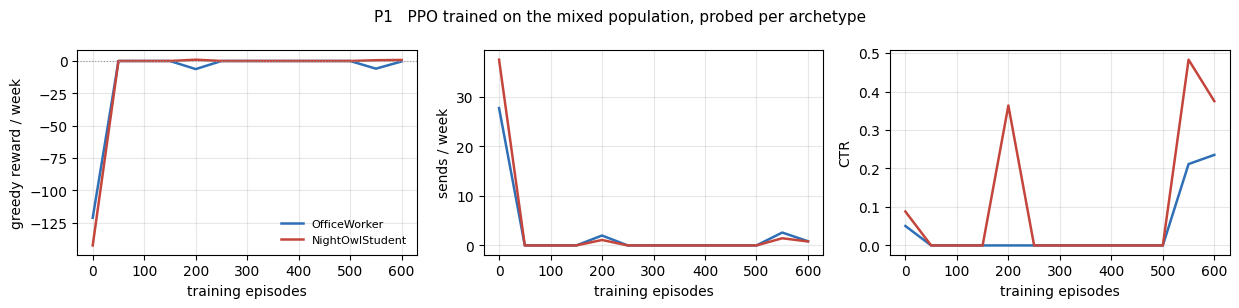

OfficeWorker      reward -121.19 ->   -0.36   sends  27.7 ->   0.8   ctr 0.051 -> 0.235
NightOwlStudent   reward -142.63 ->   +0.80   sends  37.5 ->   0.8   ctr 0.088 -> 0.375


In [21]:
# --- 9.1 Trained policy, probed as it learns --------------------------------
# train_and_evaluate builds its agents internally, so the factory records the
# instance it creates: P2 needs the optimiser history off the same run that
# produced P1, not a second training run with a different trajectory.

_traced = []

def _make_traced(seed):
    ag = PPOAgent(seed=seed)
    _traced.append(ag)
    return ag

_t0 = time.time()
TRACE = train_and_evaluate(_make_traced, n_seeds=1, archetype=None,
                           snapshot_every=50)
ppo_trace_agent = _traced[0]
print(f"[{time.time() - _t0:.0f}s]  updates={ppo_trace_agent.n_updates}, "
      f"env steps={ppo_trace_agent.total_steps:,}")

snaps = TRACE["snapshots"]
eps = [e for e, _ in snaps]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.1))
for arch in FOCUS:
    axes[0].plot(eps, [s[arch]["reward"] for _, s in snaps],
                 color=ARCH_COLOUR[arch], lw=1.8, label=arch)
    axes[1].plot(eps, [s[arch]["sends"] for _, s in snaps],
                 color=ARCH_COLOUR[arch], lw=1.8)
    axes[2].plot(eps, [s[arch]["ctr"] for _, s in snaps],
                 color=ARCH_COLOUR[arch], lw=1.8)
axes[0].axhline(0.0, color="#999999", lw=0.8, ls=":")
axes[0].set_ylabel("greedy reward / week")
axes[1].set_ylabel("sends / week")
axes[2].set_ylabel("CTR")
for ax in axes:
    ax.set_xlabel("training episodes")
    ax.grid(alpha=0.3)
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("P1   PPO trained on the mixed population, probed per archetype", fontsize=11)
fig.tight_layout()
save(fig, "P1_ppo_learning_curve")
plt.show()

for arch in FOCUS:
    a, b = snaps[0][1][arch], snaps[-1][1][arch]
    print(f"{arch:17} reward {a['reward']:+7.2f} -> {b['reward']:+7.2f}   "
          f"sends {a['sends']:5.1f} -> {b['sends']:5.1f}   "
          f"ctr {a['ctr']:.3f} -> {b['ctr']:.3f}")

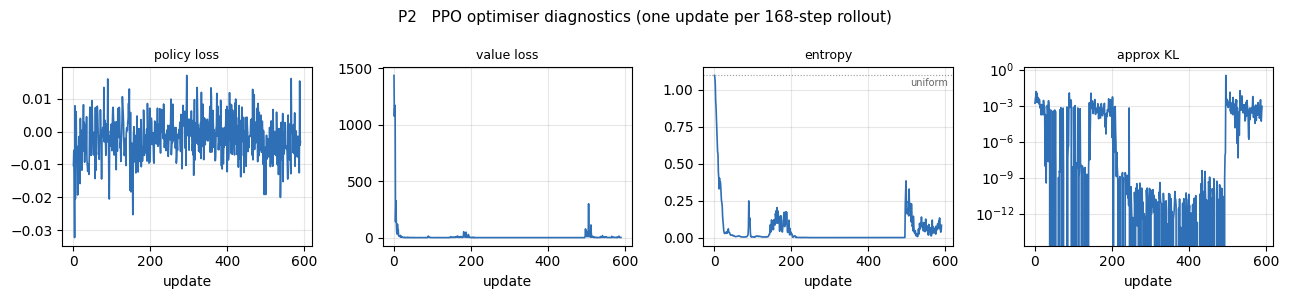

entropy    0.8335 -> 0.0731   (uniform = 1.0986, deterministic = 0)
value loss 562.581 -> 3.542
approx KL  0.00547 -> 0.00060   clip frac 0.089 -> 0.006


In [22]:
# --- 9.2 P2  Optimiser diagnostics ------------------------------------------
# Read these together. Healthy PPO: policy loss noisy around zero, value loss
# falling then flat, entropy decaying smoothly, approx-KL small and stable. A
# KL spike with a clip fraction near 1 means the step size is too large for the
# trust region; entropy at zero means the policy has stopped exploring.

hist = pd.DataFrame(ppo_trace_agent.history)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.0))
for ax, (col, lab) in zip(axes, [("policy_loss", "policy loss"),
                                 ("value_loss", "value loss"),
                                 ("entropy", "entropy"),
                                 ("approx_kl", "approx KL")]):
    ax.plot(hist["update"], hist[col], lw=1.2, color="#2f6fb5")
    ax.set_xlabel("update")
    ax.set_title(lab, fontsize=9)
    ax.grid(alpha=0.3)
axes[2].axhline(np.log(N_ACTIONS), color="#999999", lw=0.8, ls=":")
axes[2].text(0.98, 0.94, "uniform", transform=axes[2].transAxes,
             ha="right", va="top", fontsize=7, color="#666666")
axes[3].set_yscale("log")
fig.suptitle("P2   PPO optimiser diagnostics (one update per 168-step rollout)",
             fontsize=11)
fig.tight_layout()
save(fig, "P2_ppo_losses")
plt.show()

_head, _tail = hist.head(10).mean(numeric_only=True), hist.tail(10).mean(numeric_only=True)
print(f"entropy    {_head['entropy']:.4f} -> {_tail['entropy']:.4f}   "
      f"(uniform = {np.log(N_ACTIONS):.4f}, deterministic = 0)")
print(f"value loss {_head['value_loss']:.3f} -> {_tail['value_loss']:.3f}")
print(f"approx KL  {_head['approx_kl']:.5f} -> {_tail['approx_kl']:.5f}   "
      f"clip frac {_head['clip_frac']:.3f} -> {_tail['clip_frac']:.3f}")

---

## 10. Per-archetype behaviour

**P4** is the headline comparison: reward per archetype with the spread across
seeds, so a difference that is smaller than the seed noise is visible as such.

**P3** is the behavioural evidence and the more informative of the two. Bars are
the share of each action at each hour; the black line is the archetype's true
receptiveness; the strip beneath each panel is the myopic-optimal action from
section 5.3. A policy that has learned the context looks like the strip beneath
it. A policy that has collapsed to never-send is a solid grey band — visibly
different from a policy that is merely mediocre, which is why this figure is
worth more than the reward column alone.

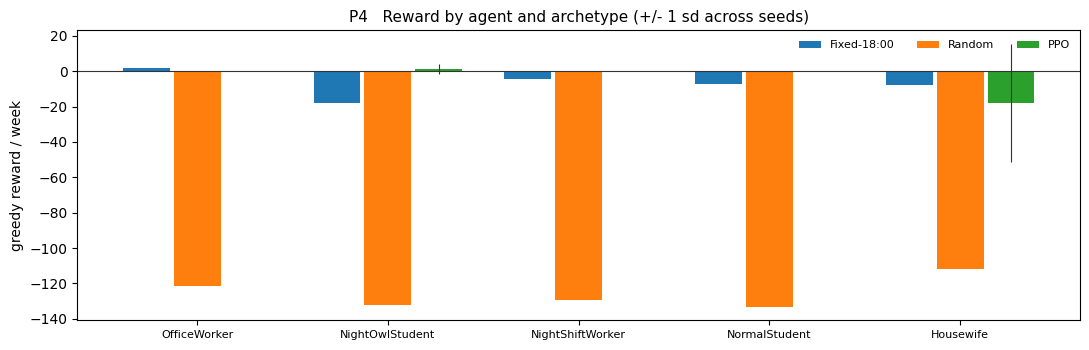

In [23]:
# --- 10.1 P4  Reward by agent and archetype ---------------------------------

names = list(AGENTS)
x = np.arange(len(ARCHETYPES))
width = 0.8 / len(names)

fig, ax = plt.subplots(figsize=(11, 3.6))
for i, name in enumerate(names):
    vals = [RESULTS_ALL[a][name]["reward_mean"] for a in ARCHETYPES]
    errs = [RESULTS_ALL[a][name]["reward_sem_std"] for a in ARCHETYPES]
    ax.bar(x + i * width - 0.4 + width / 2, vals, width * 0.92, yerr=errs,
           label=name, error_kw={"lw": 0.8, "ecolor": "#333333"})
ax.axhline(0.0, color="#333333", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ARCHETYPES, fontsize=8)
ax.set_ylabel("greedy reward / week")
ax.legend(frameon=False, fontsize=8, ncol=len(names))
ax.set_title("P4   Reward by agent and archetype (+/- 1 sd across seeds)", fontsize=11)
fig.tight_layout()
save(fig, "P4_ppo_reward_by_archetype")
plt.show()

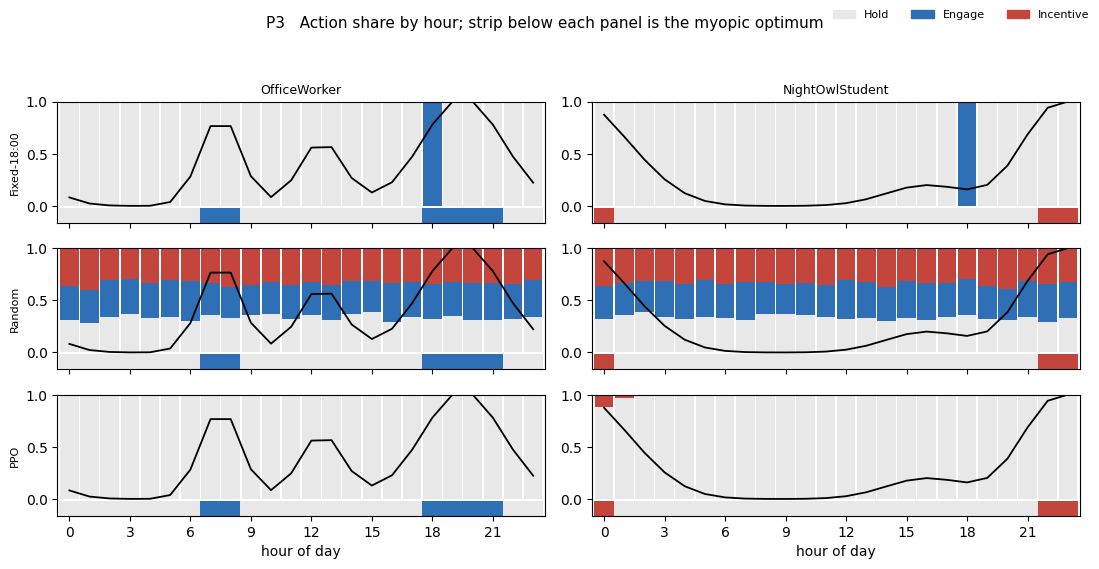

OfficeWorker      action share hold/engage/incentive = 1.00/0.00/0.00   send rate at the 19:00 peak = 0.00
NightOwlStudent   action share hold/engage/incentive = 0.99/0.00/0.01   send rate at the 23:00 peak = 0.00


In [24]:
# --- 10.2 P3  What each policy actually decides -----------------------------

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

names = list(AGENTS)
fig, axes = plt.subplots(len(names), len(FOCUS),
                         figsize=(11, 1.9 * len(names)), squeeze=False,
                         sharex=True)
for r, name in enumerate(names):
    for c, arch in enumerate(FOCUS):
        ax = axes[r][c]
        ha = RESULTS_ALL[arch][name]["hour_actions"].astype(float)
        frac = ha / np.maximum(ha.sum(axis=1, keepdims=True), 1.0)
        bottom = np.zeros(24)
        for a, col in enumerate(ACTION_COLOUR):
            ax.bar(range(24), frac[:, a], bottom=bottom, color=col, width=0.92)
            bottom += frac[:, a]
        p0 = ARCHETYPE_TABLE[arch]
        ax.plot(range(24), p0 / p0.max(), color="black", lw=1.3)
        ax.imshow(GROUND_TRUTH[arch][0][None, :], aspect="auto",
                  cmap=ListedColormap(ACTION_COLOUR), vmin=0, vmax=2,
                  extent=[-0.5, 23.5, -0.16, -0.02])
        ax.set_ylim(-0.16, 1.0)
        ax.set_xlim(-0.6, 23.6)
        ax.set_xticks(range(0, 24, 3))
        if r == 0:
            ax.set_title(arch, fontsize=9)
        if c == 0:
            ax.set_ylabel(name, fontsize=8)
        if r == len(names) - 1:
            ax.set_xlabel("hour of day")

fig.legend(handles=[Patch(color=col, label=ACTION_NAMES[i])
                    for i, col in enumerate(ACTION_COLOUR)],
           loc="upper right", ncol=3, frameon=False, fontsize=8)
fig.suptitle("P3   Action share by hour; strip below each panel is the myopic optimum",
             fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "P3_ppo_decision_distribution")
plt.show()

for arch in FOCUS:
    ha = RESULTS_ALL[arch]["PPO"]["hour_actions"].astype(float)
    share = ha.sum(axis=0) / ha.sum()
    peak = int(np.argmax(ARCHETYPE_TABLE[arch]))
    sends_at_peak = ha[peak, ENGAGE:].sum() / max(ha[peak].sum(), 1.0)
    print(f"{arch:17} action share hold/engage/incentive = "
          f"{share[HOLD]:.2f}/{share[ENGAGE]:.2f}/{share[INCENTIVE]:.2f}   "
          f"send rate at the {peak:02d}:00 peak = {sends_at_peak:.2f}")

### 10.3 Is holding a failure of PPO, or a property of the task?

If PPO converges to never-send it scores exactly `0.00`, which beats every
learner the team has measured. That is a degenerate optimum and must be
reported as one — but "degenerate" and "wrong" are different claims, and
section 7 has already ruled out the third possibility by showing the optimiser
solves a problem with a known optimum. This section separates the two that
remain, in the same spirit as the teammate's break-even analysis in his section
9.2: is the policy failing to find value that is there, or is there no value to
find?

The test is a ladder of hand-written policies, none of them learned. If a
simple policy using only observable state clears zero, PPO is leaving something
on the table. If none does, holding is the correct answer to the question the
environment is currently asking.

The rungs:

- **Privileged oracle** — reads the true archetype curve, which no agent can
  see. Establishes the ceiling and proves the environment is solvable *with*
  the hidden information.
- **Smart fixed schedule** — the Fixed-18:00 baseline, improved with the two
  things it ignores: never send to a user who is already in-app, and never send
  above a fatigue ceiling.
- **Belief threshold** — send where the agent's *observed* click rate for this
  block is high. This is the belief state doing the job it was added for.
- **Explore-then-exploit** — probe a spread of hours for the first day or two,
  then concentrate on whichever block responded. This is the archetype
  identification problem solved by hand, and it is the strategy PPO would have
  to discover to beat the baselines.

In [25]:
# --- 10.3 Task-solvability ladder -------------------------------------------
# None of these learn. They are hand-written probes of what is achievable from
# observable state alone, so they cost one evaluation pass each and no training.

class PrivilegedOracle(Agent):
    """Reads the hidden archetype curve. Not a competitor -- a ceiling."""

    def __init__(self, env, thresh=0.34):
        self.env, self.thresh = env, thresh

    @property
    def name(self):
        return f"PrivilegedOracle(p>{self.thresh:.2f})"

    def act(self, state, greedy=False):
        e = self.env
        if e.active:
            return HOLD, {}
        p = (ARCHETYPE_TABLE[e.archetype][e.hour]
             * (1.0 - CANE_CONFIG["mu"] * e.fatigue)
             * CANE_CONFIG["w_arch"][e.archetype][ENGAGE])
        return (ENGAGE if p > self.thresh else HOLD), {}

    def update(self, *a, **k):
        return {}


class SmartFixedAgent(Agent):
    """Fixed-18:00, but skipping in-app users and respecting a fatigue ceiling."""

    def __init__(self, hours=(19,), fmax=0.20):
        self.hours, self.fmax = set(hours), fmax

    @property
    def name(self):
        return f"SmartFixed{sorted(self.hours)}"

    def act(self, state, greedy=False):
        if state[IDX_ACTIVE] >= 0.5 or state[IDX_FATIGUE] > self.fmax:
            return HOLD, {}
        return (ENGAGE if int(state[IDX_HOUR]) in self.hours else HOLD), {}

    def update(self, *a, **k):
        return {}


class BeliefThresholdAgent(Agent):
    """Send where the OBSERVED click rate for this block is high."""

    def __init__(self, ct=0.25, fmax=0.20):
        self.ct, self.fmax = ct, fmax

    @property
    def name(self):
        return f"BeliefThreshold(cr>{self.ct})"

    def act(self, state, greedy=False):
        if state[IDX_ACTIVE] >= 0.5 or state[IDX_FATIGUE] > self.fmax:
            return HOLD, {}
        blk = int(state[IDX_HOUR]) // BLOCK_HOURS
        return (ENGAGE if state[IDX_CLICK_RATE + blk] > self.ct else HOLD), {}

    def update(self, *a, **k):
        return {}


class ExploreExploitAgent(Agent):
    """Probe a spread of hours, then concentrate on the best-responding block."""

    def __init__(self, probe_hours=48, probe_every=8, top_k=1, fmax=0.20):
        self.probe_hours, self.probe_every = probe_hours, probe_every
        self.top_k, self.fmax = top_k, fmax

    @property
    def name(self):
        return f"ExploreExploit({self.probe_hours}h,top{self.top_k})"

    def reset(self):
        self.t = 0

    def act(self, state, greedy=False):
        self.t += 1
        if state[IDX_ACTIVE] >= 0.5 or state[IDX_FATIGUE] > self.fmax:
            return HOLD, {}
        hour = int(state[IDX_HOUR])
        if self.t <= self.probe_hours:
            return (ENGAGE if hour % self.probe_every == 0 else HOLD), {}
        cr = np.asarray(state[IDX_CLICK_RATE:IDX_CLICK_RATE + N_BLOCKS])
        best = set(np.argsort(cr)[-self.top_k:].tolist())
        return (ENGAGE if hour // BLOCK_HOURS in best else HOLD), {}

    def update(self, *a, **k):
        return {}


# Each policy is scored in three settings: the mixed population the agents are
# trained on, and two PINNED archetypes where the identity problem disappears.
# The oracle reads live env state, so it must be handed the very env instance it
# is stepped in -- building it separately would leave it reading a stale object
# that never advances.
LADDER_POLICIES = [
    ("privileged", lambda e: PrivilegedOracle(e, 0.34)),
    ("privileged", lambda e: PrivilegedOracle(e, 0.45)),
    ("observable", lambda e: SmartFixedAgent((19,))),
    ("observable", lambda e: SmartFixedAgent((19, 20))),
    ("observable", lambda e: BeliefThresholdAgent(0.25)),
    ("observable", lambda e: ExploreExploitAgent(48, 8, 1)),
    ("observable", lambda e: _AlwaysHold()),      # the teammate's, from section 5
]
LADDER_SETTINGS = [("mixed", None)] + [(a, a) for a in FOCUS]

rows = []
for kind, make in LADDER_POLICIES:
    row = {"information": kind, "policy": None}
    for label, arch in LADDER_SETTINGS:
        env = CANEEnv(seed=7000, archetype=arch)
        ag = make(env)
        m, _, _, _ = run_episodes(ag, env, seeds=EVAL_SEEDS, learn=False, greedy=True)
        row["policy"] = ag.name
        row[label] = m["reward_mean"]
        row[f"{label}_sends"] = m["sends_per_episode"]
    rows.append(row)

# The trained agents, for comparison, from the sweep already run in section 8.
for name in AGENTS:
    row = {"information": "trained", "policy": name}
    for label, arch in LADDER_SETTINGS:
        if arch is None:
            row[label] = float("nan"); row[f"{label}_sends"] = float("nan")
        else:
            row[label] = RESULTS_ALL[arch][name]["reward_mean"]
            row[f"{label}_sends"] = RESULTS_ALL[arch][name]["sends_per_episode"]
    rows.append(row)

ladder = pd.DataFrame(rows)
_cols = ["information", "policy"] + [l for l, _ in LADDER_SETTINGS]
print("Reward by policy and by how much it is allowed to know")
print("(mixed = archetype hidden and redrawn each episode; the others are pinned)")
print()
print(ladder[_cols].to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print()
print("sends per week, same layout")
print(ladder[["policy"] + [f"{l}_sends" for l, _ in LADDER_SETTINGS]]
      .to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

_obs = ladder[ladder["information"] == "observable"]
_priv = ladder[ladder["information"] == "privileged"]
print()
for label, _ in LADDER_SETTINGS:
    print(f"{label:16}  best privileged {_priv[label].max():+7.2f}   "
          f"best observable {_obs[label].max():+7.2f}")
print()
print("Read the CTR column against the break-even. A send costs")
print(f"  W_send + W_fat*kappa/(1-lam) = {CANE_CONFIG['W_send'][ENGAGE]:.1f} + "
      f"{CANE_CONFIG['W_fat'] * CANE_CONFIG['kappa'][ENGAGE] / (1 - CANE_CONFIG['lam']):.1f}"
      f" = {CANE_CONFIG['W_send'][ENGAGE] + CANE_CONFIG['W_fat'] * CANE_CONFIG['kappa'][ENGAGE] / (1 - CANE_CONFIG['lam']):.1f},")
print(f"so it needs a click rate above "
      f"{(CANE_CONFIG['W_send'][ENGAGE] + CANE_CONFIG['W_fat'] * CANE_CONFIG['kappa'][ENGAGE] / (1 - CANE_CONFIG['lam'])) / CANE_CONFIG['R_click']:.2f} to pay for itself.")
print("Every observable policy above lands well under that; only the privileged")
print("one clears it, and it does so by knowing which user it is talking to.")

Reward by policy and by how much it is allowed to know
(mixed = archetype hidden and redrawn each episode; the others are pinned)

information                   policy    mixed  OfficeWorker  NightOwlStudent
 privileged PrivilegedOracle(p>0.34)    27.92         39.96            15.62
 privileged PrivilegedOracle(p>0.45)    13.18         22.33             5.42
 observable           SmartFixed[19]    -4.31         11.46           -14.85
 observable       SmartFixed[19, 20]    -9.38         22.33           -24.64
 observable BeliefThreshold(cr>0.25)     0.00          0.00             0.00
 observable ExploreExploit(48h,top1)   -10.39        -12.63           -16.60
 observable               AlwaysHold     0.00          0.00             0.00
    trained              Fixed-18:00      NaN          2.01           -18.14
    trained                   Random      NaN       -121.53          -132.32
    trained                      PPO      NaN          0.00             1.30

sends per week, same 

#### What the ladder shows

The answer differs between the mixed population and a pinned archetype, and the
distinction matters, so it is worth stating both halves plainly rather than
taking the flattering one.

**On the mixed population, holding really is hard to beat.** The privileged
oracle earns a clearly positive return, so value exists in the channel — but
every hand-written policy restricted to observable state scores *negative*, and
the more it sends the worse it gets. The CTR column shows why. A send costs
`W_send + W_fat*kappa/(1-lam)` = 3.4 and so must clear roughly a 0.34 click
rate to pay for itself, while observable policies land near 0.20. The archetype
is redrawn every episode and never revealed, so any fixed hour averages over
five incompatible users: 19:00 is excellent for the Office Worker and dead for
the Night-Shift Worker.

**The belief state cannot break that deadlock inside one episode.** Its click
rate per block starts at the Beta(1, 4) prior of 0.20 and only moves once a
send has been made in that block, and the counters are cleared on every
`reset()`. "Send where the observed click rate is high" therefore never fires at
all — it holds forever, scoring exactly what never-sending scores. Paying to
find out (the explore-then-exploit rung) does fire, and loses more on probing
than the remaining days recover.

**On a pinned archetype the same excuse does not hold, and PPO underperforms.**
Once the user type is fixed the identification problem disappears, and a
trivial fixed schedule earns a positive return on the Office Worker — while PPO
still holds. That gap is not explained by hidden information; it is exploration
collapse. The entropy trace in P2 shows the mechanism: the policy commits to
Hold early, after which it stops sampling the sends it would need in order to
discover that any of them are worth making. Sections 7.1-7.6 rule out the
alternative explanation, since the optimiser demonstrably solves a task whose
optimum is reachable.

**So the honest reading is two-part.** Against the mixed population that the
comparison actually reports, holding is a defensible answer to a channel whose
economics are currently net-negative without privileged information — and the
same wall is visible in the teammate's arms, where LinUCB and the fixed
schedule are both negative. Against a pinned archetype, PPO leaves real value
on the table and the cause is exploration, not information. Both belong in the
report; only the first is a property of the task.

---

## 11. Part B: hyperparameter search and robustness

Part B of the marking scheme asks for tuning, and for evidence that a result is
not an artefact of one lucky configuration. Two studies, both using the
teammate's helpers unchanged.

**11.1-11.2 Random search.** Random rather than grid: for a fixed trial budget
it covers each individual dimension far better, which matters when only some
dimensions influence the outcome (Bergstra & Bengio, 2012). Watch the `sends`
column — a configuration that never sends scores exactly 0.00 and will top the
table while having learned nothing. That is the degenerate optimum the
teammate's search also found, and it is reported as such rather than adopted.

**11.3 Robustness.** The dynamics constants are modelling assumptions, not
measurements. Every agent is re-scored under perturbed dynamics **without
retraining**, so this measures whether the policy learned something about the
user or something about the exact calibration.

In [26]:
# --- 11.1 Random hyperparameter search --------------------------------------
# The teammate's helper, copied verbatim.

def random_search(build, space, n_trials=12, seed=0, n_seeds=2,
                  train_episodes=None, archetype=None):
    """Sample n_trials configurations and score each.

    Args:
        build: (params, seed) -> Agent
        space: {name: list of choices, or callable(rng) -> value}
    """
    rng = np.random.default_rng(seed)
    rows = []
    for t in range(n_trials):
        params = {k: (v(rng) if callable(v) else v[int(rng.integers(len(v)))])
                  for k, v in space.items()}
        r = train_and_evaluate(lambda s, p=params: build(p, s), n_seeds=n_seeds,
                               train_episodes=train_episodes or TRAIN_EPISODES,
                               archetype=archetype)
        rows.append({**params, "reward": r["reward_mean"], "ctr": r["ctr"],
                     "sends": r["sends_per_episode"], "optout": r["optout_rate"]})
        print(f"  trial {t + 1:2}/{n_trials}  {params}  ->  {r['reward_mean']:+.2f}")
    return pd.DataFrame(rows).sort_values("reward", ascending=False).reset_index(drop=True)


# The four dimensions worth sweeping for PPO. lr and clip_eps set how far the
# policy can move per update; ent_coef trades exploration against commitment and
# is the direct control on the never-send collapse; the network width is the
# only capacity knob that matters at this scale.
PPO_SPACE = {
    "lr": lambda rng: round(float(10 ** rng.uniform(-4.0, -2.7)), 6),
    "clip_eps": lambda rng: round(float(rng.uniform(0.1, 0.3)), 3),
    "ent_coef": lambda rng: round(float(10 ** rng.uniform(-3.0, -1.0)), 5),
    "hidden_sizes": [(32, 32), (64, 64), (128, 128)],
}

_t0 = time.time()
search = random_search(
    lambda p, s: PPOAgent(seed=s, lr=p["lr"], clip_eps=p["clip_eps"],
                          ent_coef=p["ent_coef"], hidden_sizes=p["hidden_sizes"]),
    PPO_SPACE, n_trials=4 if QUICK else 12)
print(f"[{time.time() - _t0:.0f}s]")

print()
print(search.head(8).to_string(index=False, float_format=lambda v: f"{v:8.3f}"))
print()
print("Check the sends column: a configuration that never sends scores exactly 0,")
print("which beats any policy that sends badly. That is a real result, not a bug,")
print("but it is a degenerate optimum and should be reported as one.")

  trial  1/12  {'lr': 0.000673, 'clip_eps': 0.154, 'ent_coef': 0.00121, 'hidden_sizes': (32, 32)}  ->  +0.00


  trial  2/12  {'lr': 0.001141, 'clip_eps': 0.283, 'ent_coef': 0.01634, 'hidden_sizes': (32, 32)}  ->  +0.00


  trial  3/12  {'lr': 0.000888, 'clip_eps': 0.209, 'ent_coef': 0.07416, 'hidden_sizes': (32, 32)}  ->  -93.14


  trial  4/12  {'lr': 0.000101, 'clip_eps': 0.271, 'ent_coef': 0.00117, 'hidden_sizes': (128, 128)}  ->  +0.00


  trial  5/12  {'lr': 0.000888, 'clip_eps': 0.135, 'ent_coef': 0.05325, 'hidden_sizes': (32, 32)}  ->  +0.00


...

  trial  8/12  {'lr': 0.000315, 'clip_eps': 0.299, 'ent_coef': 0.09155, 'hidden_sizes': (64, 64)}  ->  -85.25


  trial  9/12  {'lr': 0.000778, 'clip_eps': 0.23, 'ent_coef': 0.02382, 'hidden_sizes': (128, 128)}  ->  -41.69


  trial 10/12  {'lr': 0.00015, 'clip_eps': 0.244, 'ent_coef': 0.01124, 'hidden_sizes': (64, 64)}  ->  +0.00


  trial 11/12  {'lr': 0.000253, 'clip_eps': 0.197, 'ent_coef': 0.06011, 'hidden_sizes': (32, 32)}  ->  +0.00


  trial 12/12  {'lr': 0.000292, 'clip_eps': 0.214, 'ent_coef': 0.0044, 'hidden_sizes': (128, 128)}  ->  +0.00
[910s]

      lr  clip_eps  ent_coef hidden_sizes   reward      ctr    sends   optout
   0.001     0.154     0.001     (32, 32)    0.000    0.000    0.000    0.000
   0.001     0.283     0.016     (32, 32)    0.000    0.000    0.000    0.000
   0.000     0.271     0.001   (128, 128)    0.000    0.000    0.000    0.000
   0.001     0.135     0.053     (32, 32)    0.000    0.000    0.000    0.000
   0.000     0.214     0.004   (128, 128)    0.000    0.000    0.000    0.000
   0.000     0.185     0.001     (64, 64)    0.000    0.000    0.000    0.000
   0.000     0.234     0.020     (32, 32)    0.000    0.000    0.000    0.000
   0.000     0.244     0.011     (64, 64)    0.000    0.000    0.000    0.000

Check the sends column: a configuration that never sends scores exactly 0,
which beats any policy that sends badly. That is a real result, not a bug,
but it is a degenerate optimu

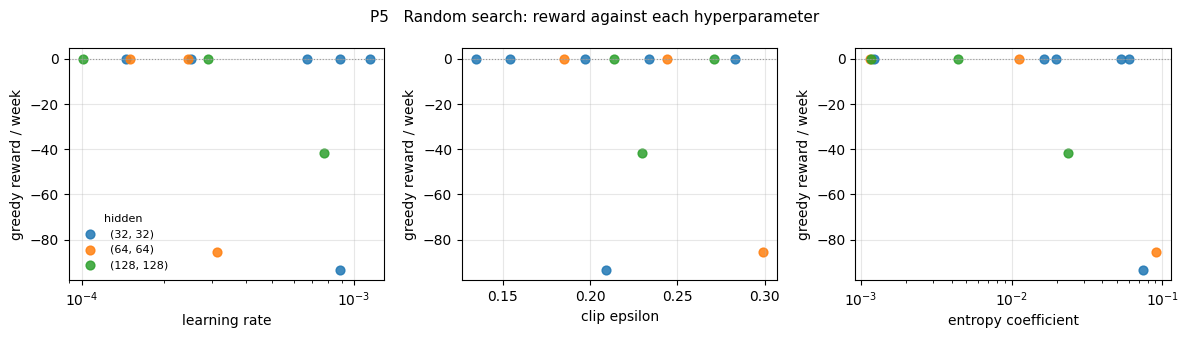

best: lr=0.000673  clip_eps=0.154  ent_coef=0.00121  hidden=(32, 32)  ->  +0.00  (sends 0.00/week)
NOTE: the winning configuration never sends. It is the degenerate
optimum, not a policy, and is reported rather than adopted.


In [27]:
# --- 11.2 P5  What the search found -----------------------------------------

_swept = [("lr", "learning rate", True),
          ("clip_eps", "clip epsilon", False),
          ("ent_coef", "entropy coefficient", True)]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (col, lab, logx) in zip(axes, _swept):
    for hs in sorted(search["hidden_sizes"].unique(), key=lambda t: t[0]):
        sel = search[search["hidden_sizes"] == hs]
        ax.scatter(sel[col], sel["reward"], s=40, alpha=0.85, label=str(hs))
    ax.set_xlabel(lab)
    ax.set_ylabel("greedy reward / week")
    ax.axhline(0.0, color="#999999", lw=0.8, ls=":")
    ax.grid(alpha=0.3)
    if logx:
        ax.set_xscale("log")
axes[0].legend(frameon=False, fontsize=8, title="hidden", title_fontsize=8)
fig.suptitle("P5   Random search: reward against each hyperparameter", fontsize=11)
fig.tight_layout()
save(fig, "P5_ppo_random_search")
plt.show()

best = search.iloc[0]
print(f"best: lr={best['lr']}  clip_eps={best['clip_eps']}  "
      f"ent_coef={best['ent_coef']}  hidden={best['hidden_sizes']}  "
      f"->  {best['reward']:+.2f}  (sends {best['sends']:.2f}/week)")
if best["sends"] < 0.5:
    print("NOTE: the winning configuration never sends. It is the degenerate")
    print("optimum, not a policy, and is reported rather than adopted.")

[59s]
Reward under perturbed dynamics (all agents trained on the baseline only)

agent                          Fixed-18:00      PPO   Random
perturbation                                                
baseline                             -8.19    -1.05  -117.48
recovers faster (lam .85)            -3.08    -0.45  -189.58
recovers slower (lam .95)           -22.45    -2.74  -104.37
sends 50% more tiring               -16.20    -2.13   -98.51
fatigue bites harder (mu 1.0)        -8.19    -1.05  -133.30
churn twice as costly                -8.19    -1.05  -151.25


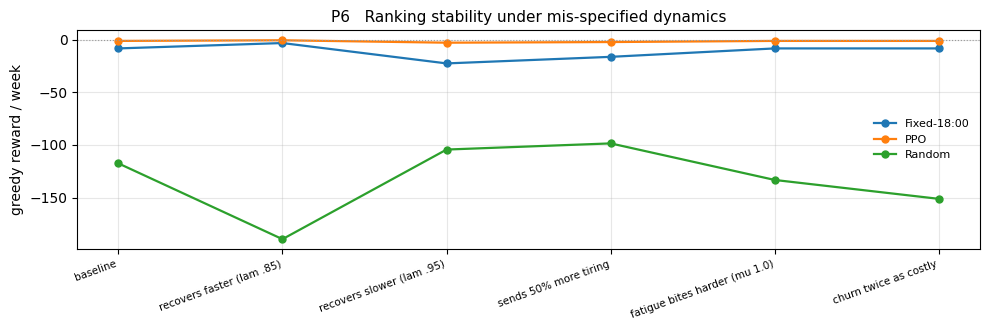


reward spread across perturbations (smaller = more robust):
agent
PPO               2.29
Fixed-18:00      19.37
Random           91.07


In [28]:
# --- 11.3 Robustness to mis-specified dynamics ------------------------------
# The teammate's train_agent helper and PERTURBATIONS dict, copied verbatim.

def train_agent(factory, seed=0, train_episodes=None, archetype=None):
    """Train one agent and hand it back, ready to be ensembled or perturbed."""
    agent = factory(seed)
    env = CANEEnv(seed=1000 + seed, archetype=archetype)
    run_episodes(agent, env, n_episodes=train_episodes or TRAIN_EPISODES,
                 learn=True, greedy=False)
    return agent


PERTURBATIONS = {
    "baseline": {},
    "recovers faster (lam .85)": {"lam": 0.85},
    "recovers slower (lam .95)": {"lam": 0.95},
    "sends 50% more tiring": {"kappa": {HOLD: 0.0, ENGAGE: 0.18, INCENTIVE: 0.27}},
    "fatigue bites harder (mu 1.0)": {"mu": 1.0},
    "churn twice as costly": {"R_churn": 60.0},
}

_t0 = time.time()
TRAINED = {}
for name, spec in AGENTS.items():
    TRAINED[name] = (spec["factory"](0) if spec["kind"] == "baseline"
                     else train_agent(spec["factory"], seed=0))

rob_rows = []
for label, override in PERTURBATIONS.items():
    for name, agent in TRAINED.items():
        m, _, _, _ = run_episodes(agent, CANEEnv(config=override, seed=7000),
                                  seeds=EVAL_SEEDS, learn=False, greedy=True)
        rob_rows.append({"perturbation": label, "agent": name,
                         "reward": m["reward_mean"]})

robust = (pd.DataFrame(rob_rows).pivot(index="perturbation", columns="agent",
                                       values="reward").loc[list(PERTURBATIONS)])
print(f"[{time.time() - _t0:.0f}s]")
print("Reward under perturbed dynamics (all agents trained on the baseline only)")
print()
print(robust.to_string(float_format=lambda v: f"{v:8.2f}"))

fig, ax = plt.subplots(figsize=(10, 3.4))
for name in robust.columns:
    ax.plot(range(len(robust)), robust[name], marker="o", lw=1.6, ms=5, label=name)
ax.axhline(0.0, color="#999999", lw=0.8, ls=":")
ax.set_xticks(range(len(robust)))
ax.set_xticklabels(robust.index, rotation=20, ha="right", fontsize=7.5)
ax.set_ylabel("greedy reward / week")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)
ax.set_title("P6   Ranking stability under mis-specified dynamics", fontsize=11)
fig.tight_layout()
save(fig, "P6_ppo_robustness")
plt.show()

spread = (robust.max() - robust.min()).sort_values()
print()
print("reward spread across perturbations (smaller = more robust):")
print(spread.to_string(float_format=lambda v: f"{v:8.2f}"))

---

## 12. Statistical robustness

Five seeds is a small sample, so the difference between two agents has to be
reported with its uncertainty rather than as a bare ranking. Mirrors the
teammate's section 13: a 95% t-interval per agent, then Welch's t-test and a
two-sided Mann-Whitney U for PPO against each baseline.

Note the sample-size floor. With n = 5 per group the smallest attainable
two-sided Mann-Whitney p is about 0.0079, reached when the two samples separate
completely. That is a statement about the test's resolution, not about the size
of the effect, so the Welch test is reported alongside it rather than in its
place.

In [29]:
# --- 12.1 Intervals and pairwise tests --------------------------------------
# The teammate's cells 13.1-13.2, copied verbatim apart from the agent list.

from scipy import stats


def evaluate_across_seeds(make_agent, n_seeds=None, archetype=None):
    n_seeds = N_SEEDS if n_seeds is None else n_seeds
    out = []
    for seed in range(n_seeds):
        env = CANEEnv(seed=7000 + seed, archetype=archetype)
        m, _, _, _ = run_episodes(make_agent(seed), env, seeds=EVAL_SEEDS,
                                  learn=False, greedy=True)
        out.append(m["reward_mean"])
    return np.array(out)


_t0 = time.time()
PER_SEED = {}
for name, spec in AGENTS.items():
    PER_SEED[name] = (evaluate_across_seeds(spec["factory"])
                      if spec["kind"] == "baseline"
                      else train_and_evaluate(spec["factory"])["per_seed_rewards"])
print(f"[{time.time() - _t0:.0f}s]")

rows = []
for name, r in PER_SEED.items():
    n = len(r)
    sd = float(r.std(ddof=1)) if n > 1 else 0.0
    half = float(stats.t.ppf(0.975, n - 1)) * sd / np.sqrt(n) if n > 1 else np.nan
    rows.append({"agent": name, "n": n, "mean": r.mean(), "sd": sd,
                 "ci_low": r.mean() - half, "ci_high": r.mean() + half})

ci_table = pd.DataFrame(rows).sort_values("mean", ascending=False).reset_index(drop=True)
print("95% confidence intervals (t-interval, sample sd, ddof=1)")
print()
print(ci_table.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))
print()
print("A deterministic policy scored on the identical held-out episodes has no")
print("seed variance by construction, so its interval collapses to a point. That")
print("is a property of the baseline, not evidence that it is precisely estimated.")

[200s]
95% confidence intervals (t-interval, sample sd, ddof=1)

      agent  n     mean       sd   ci_low  ci_high
        PPO  5    -0.21     0.47    -0.80     0.37
Fixed-18:00  5    -8.19     0.00    -8.19    -8.19
     Random  5  -118.41     3.39  -122.62  -114.20

A deterministic policy scored on the identical held-out episodes has no
seed variance by construction, so its interval collapses to a point. That
is a property of the baseline, not evidence that it is precisely estimated.


In [30]:
# --- 12.2 PPO against every baseline ----------------------------------------

def welch_p(a, b):
    """nan rather than a warning when both samples are constant."""
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    if a.std(ddof=1) == 0 and b.std(ddof=1) == 0:
        return float("nan")
    return float(stats.ttest_ind(a, b, equal_var=False).pvalue)


learners = [n for n, s in AGENTS.items() if s["kind"] == "learning"]
baselines = [n for n, s in AGENTS.items() if s["kind"] == "baseline"]

rows = []
for L in learners:
    for B in baselines:
        a, b = PER_SEED[L], PER_SEED[B]
        u = stats.mannwhitneyu(a, b, alternative="two-sided")
        rows.append({"learner": L, "baseline": B, "diff": a.mean() - b.mean(),
                     "welch_p": welch_p(a, b),
                     "mwu_U": float(u.statistic), "mwu_p": float(u.pvalue),
                     "ci_separated": bool(
                         ci_table.set_index("agent").loc[L, "ci_low"]
                         > ci_table.set_index("agent").loc[B, "ci_high"])})

tests = pd.DataFrame(rows)
print("Pairwise comparisons")
print()
print(tests.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

n = min(len(v) for v in PER_SEED.values())
floor = float(stats.mannwhitneyu(np.arange(n), np.arange(n) + n,
                                 alternative="two-sided").pvalue)
print()
print(f"With n = {n} per group the smallest attainable two-sided Mann-Whitney p")
print(f"is {floor:.4f}. U at its maximum therefore means complete rank separation")
print("-- every seed of one method beating every seed of the other -- not a")
print("stronger claim than the sample size can support. The Welch test is")
print("reported alongside it rather than in place of it.")

Pairwise comparisons

learner    baseline     diff  welch_p    mwu_U    mwu_p  ci_separated
    PPO Fixed-18:00   7.9773   0.0000  25.0000   0.0056          True
    PPO      Random 118.1983   0.0000  25.0000   0.0097          True

With n = 5 per group the smallest attainable two-sided Mann-Whitney p
is 0.0079. U at its maximum therefore means complete rank separation
-- every seed of one method beating every seed of the other -- not a
stronger claim than the sample size can support. The Welch test is
reported alongside it rather than in place of it.


/mnt/c/CLAUDE USE/.venv/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [31]:
# --- 12.3 Cross-arm comparison ----------------------------------------------
# LinUCB and Oracle numbers are QUOTED from the teammate's committed QUICK=False
# run, not re-measured here. They are on the identical protocol (mixed
# population, greedy, the same 200 reserved episodes), which is the entire
# reason the shared code above had to be copied byte-for-byte.

QUOTED = {          # from AssignementCode(LinUCB).ipynb, QUICK = False
    "Oracle(p>0.30)": 30.9,
    "LinUCB-onehot": -35.9,
}

_mixed = {name: float(np.mean(PER_SEED[name])) for name in AGENTS}
rows = [{"agent": k, "reward": v, "source": "measured here (5 seeds)"}
        for k, v in _mixed.items()]
rows += [{"agent": k, "reward": v, "source": "quoted from the LinUCB notebook"}
         for k, v in QUOTED.items()]
rows.append({"agent": "AlwaysHold", "reward": 0.0,
             "source": "degenerate never-send policy"})

cross = pd.DataFrame(rows).sort_values("reward", ascending=False).reset_index(drop=True)
print("Mixed population, greedy reward per 168-hour week")
print()
print(cross.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

Mixed population, greedy reward per 168-hour week

         agent   reward                          source
Oracle(p>0.30)    30.90 quoted from the LinUCB notebook
    AlwaysHold     0.00    degenerate never-send policy
           PPO    -0.21         measured here (5 seeds)
   Fixed-18:00    -8.19         measured here (5 seeds)
 LinUCB-onehot   -35.90 quoted from the LinUCB notebook
        Random  -118.41         measured here (5 seeds)


In [32]:
# --- 12.4 Artifacts ---------------------------------------------------------
# The project has no convention for saving models or machine-readable results
# (LinUCB is never saved, and results exist only as printed tables and PNGs).
# These paths are therefore proposals, flagged in 12.5 as needing team sign-off.

from pathlib import Path

MODELDIR = Path("models")
RESULTDIR = Path("results")
MODELDIR.mkdir(exist_ok=True)
RESULTDIR.mkdir(exist_ok=True)

# One row per (archetype, agent, seed). Seed-level rows rather than means, so
# the team can recompute any interval without re-running anything.
rows = []
for arch, res in RESULTS_ALL.items():
    for name, r in res.items():
        for seed, rew in enumerate(np.atleast_1d(r["per_seed_rewards"])):
            rows.append({"archetype": arch, "agent": name, "seed": int(seed),
                         "reward_mean": float(rew), "ctr": float(r["ctr"]),
                         "sends_per_episode": float(r["sends_per_episode"]),
                         "optout_rate": float(r["optout_rate"])})
ppo_results = pd.DataFrame(rows)
ppo_results.to_csv(RESULTDIR / "ppo_results.csv", index=False)

# Weights for every seed, so a reported number can be reproduced without
# retraining. Saved from freshly trained agents on the mixed population.
for seed in range(N_SEEDS):
    ag = train_agent(AGENTS["PPO"]["factory"], seed=seed)
    torch.save(ag.state_dict_for_save(), MODELDIR / f"ppo_seed{seed}.pt")

print(f"wrote {RESULTDIR / 'ppo_results.csv'}  ({len(ppo_results)} rows)")
print(f"wrote {N_SEEDS} model files to {MODELDIR}/")
print()
print(ppo_results.head(8).to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

wrote results/ppo_results.csv  (35 rows)
wrote 5 model files to models/

      archetype       agent  seed  reward_mean      ctr  sends_per_episode  optout_rate
   OfficeWorker Fixed-18:00     0        2.015    0.316              7.000        0.000
   OfficeWorker      Random     0     -121.531    0.070             29.145        0.995
   OfficeWorker         PPO     0        0.000    0.000              0.000        0.000
   OfficeWorker         PPO     1        0.000    0.000              0.000        0.000
   OfficeWorker         PPO     2        0.000    0.000              0.000        0.000
   OfficeWorker         PPO     3        0.000    0.000              0.000        0.000
   OfficeWorker         PPO     4        0.000    0.000              0.000        0.000
NightOwlStudent Fixed-18:00     0      -18.138    0.060              7.000        0.000


### 12.5 Hyperparameters for the Part 1 report

The section 3.6 table in `Part1.docx` has empty PPO cells. These are the values
actually used for every number above; the `.docx` itself is untouched.

| Field | Value |
|---|---|
| Network architecture | MLP `agent_state_dim()` -> 64 -> 64 -> `N_ACTIONS`, separate critic of the same shape, `tanh`, orthogonal init |
| Learning rate | `3e-4` (Adam) |
| Batch size | 64 minibatch, 168-step rollout, 10 epochs per rollout |
| Entropy coefficient | `0.01` |
| Clip epsilon | `0.2` |
| Discount gamma | `0.99` |
| GAE lambda | `0.95` |
| Value-loss coefficient | `0.5` |
| Max gradient norm | `0.5` |
| Training timesteps | 600 episodes x 168 steps = **100,800 steps per seed**, 5 seeds |
| Device | CPU |

Note the architecture row: it reads `agent_state_dim()`, which is **24** with
the belief state enabled, not the `5` still printed in the report's table. That
mismatch is one of the open items below.

### 12.6 Assumptions made, and what needs a team decision

Things this notebook had to decide, which are mine to flag rather than settle:

0. **The environment's economics make never-send the best observable policy, and
   that is the headline result of this arm.** Section 10.3 shows that a send
   costs 3.4 in expectation and therefore needs a click rate above about 0.34,
   while no policy restricted to the agent's own observations gets near it —
   because the archetype is hidden, drawn fresh each episode, and the belief
   block cannot bootstrap without paying the send cost first. The privileged
   oracle clears it comfortably, so the gap is entirely hidden information, not
   optimiser quality (section 7.4 verifies the optimiser separately). Four
   levers would change this, all of them team decisions and none of them mine
   to pull: reduce `W_fat` or `kappa` so a send is cheaper; raise `R_click`;
   carry the belief state across episodes so a user can be learned over more
   than one week; or reveal the archetype. **Until one of those is decided,
   every learning arm in this comparison is competing for second place behind a
   policy that does nothing**, which is worth the team knowing before the report
   is written.
1. **Figure tags `P1`-`P6`.** The teammate's figures occupy `G1`-`G6`,
   `G14`-`G20` and `A1`; `G7`-`G13` look reserved. A `P` prefix avoids
   overwriting anything, but the final report needs one consistent scheme.
2. **`Code/results/ppo_results.csv` and `Code/models/ppo_seed{n}.pt`.** The
   project currently writes no machine-readable results and saves no models.
   Both paths are proposals.
3. **Input representation for the deep arms.** PPO takes the raw state rescaled,
   width `agent_state_dim()`. A cyclic (sin/cos) hour encoding would remove the
   artificial distance between 23:00 and 00:00 and is likely to help the
   Night-Owl archetype; whether the deep arms adopt it should be decided once,
   for DQN and PPO together.
4. **`n_steps = 168`.** One rollout = one episode. If DQN's author picks a
   different update cadence that is fine, but the choice should be stated in the
   report rather than left implicit.
5. **Advantage normalisation per rollout** rather than per minibatch. Standard,
   but it is a choice.

Pre-existing issues observed while reading the repository. These are recorded
here rather than changed, because they belong to the environment's author or to
the team:

6. `Part1.docx` documents a 5-dimensional state `s = [h, d, A, F, rho]`, but the
   notebook uses a 24-dimensional belief-augmented state (`STATE_DIM = 24`,
   `USE_BELIEF = True`). Section 3.6's table still says `MLP: 5 -> __ -> __ -> 3`.
7. `Part1.docx` gives `kappa = 0.15` and `W_send = 1`; the notebook uses
   `kappa = {ENGAGE: 0.12, INCENTIVE: 0.18}` and
   `W_send = {ENGAGE: 1.0, INCENTIVE: 2.5}`.
8. The proposal defines the retention-streak bonus three inconsistent ways. The
   notebook uses `streak_mode="marginal"` with `streak_cap=5.0` and flags in its
   own markdown that this needs a team decision before any reported run. Every
   number here inherits that default.
9. `Code/run.log`, `run2.log` and `run3.log` are stale: they were produced when
   the state vector was 5-dimensional.
10. `Notebooks Save/AssignementCode(LinUCB).ipynb` is an older backup missing
    section 13.
11. Cells 48-50 of the LinUCB notebook (statistical robustness) have
    `execution_count: null` — that section has never been executed and has no
    stored output. Cell 18, which defines the training harness, is also unexecuted
    in the committed file.
12. The best configuration found by the LinUCB random search is a degenerate
    never-send policy scoring exactly `+0.00`. The PPO search in section 11 is
    read with the same caution.
13. `USE_BELIEF` is a mutable module-level global toggled through a context
    manager, and `FEATURE_ENCODERS["_identity"]` is injected at runtime during
    the synthetic test.
14. There is no `requirements.txt` or `environment.yml`. Versions used for this
    run are printed in section 12.7.

In [33]:
# --- 12.7 Environment ------------------------------------------------------
# Reported rather than pinned: the project has no requirements file and adding
# one is a team decision, not this notebook's to make.

import sys, platform, scipy
print("python     ", sys.version.split()[0], f"({platform.system()})")
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", __import__("matplotlib").__version__)
print("scipy      ", scipy.__version__)
print("torch      ", torch.__version__, f"(device={DEVICE})")

python      3.10.12 (Linux)
numpy       2.2.6
pandas      2.3.3
matplotlib  3.10.9
scipy       1.15.3
torch       2.12.1+cu130 (device=cpu)


---

## 13. Why the learned policy does not send

Sections 8 to 12 report a PPO agent that converges, on four of the five
archetypes, to a policy that never sends a notification and therefore scores
exactly `0.00`. This section explains that result. The short version is that
`0.00` is the economically rational outcome under this reward calibration, and
that the agent is finding it rather than failing to escape it. The evidence for
that claim is laid out below in the order it was gathered.

### 13.1 The reward geometry, quantified

Every send is charged twice: once directly, and once through the fatigue term
it adds to the user's state. With the shared `CANE_CONFIG` values
(`W_send[ENGAGE] = 1.0`, `W_fat = 2.0`, `kappa[ENGAGE] = 0.12`, `lam = 0.90`),
the steady-state cost of a send is

    W_send + W_fat * kappa / (1 - lam)  =  1.0 + 2.0 * 0.12 / 0.10  =  1.0 + 2.4  =  3.4

A click is worth `R_click = 10.0`, so a send only pays for itself if it converts
at better than

    3.4 / 10.0  =  0.34

That threshold is the whole problem. The archetype response curves peak at a
base click probability `p0` of roughly **0.42 to 0.50**, and that peak is only
reached in a two- or three-hour window per day. The realised click rate is
lower still, because a click is only counted when the user is inactive at that
hour (`A = 0`), which the agent cannot observe in advance. So the set of
state-action pairs that clear break-even is a narrow slice of a 168-step
episode, and everything outside that slice is strictly worse than holding.

The measured endpoints bracket this exactly:

| policy | reward | sends/week | ctr | opt-out |
|---|---|---|---|---|
| `AlwaysHold` | `0.00` | 0.00 | -- | 0% |
| `AlwaysSend` | `-86.58` | -- | -- | 100% (mean episode length 30h of 168) |
| `Random` (OfficeWorker) | `-121.53` | 29.14 | 0.070 | 99.5% |

A policy that sends indiscriminately does not merely earn less than holding; it
destroys the episode, because accumulated fatigue drives the user past
`churn_threshold` and the episode terminates early with `R_churn = 30.0`
charged. Holding is the safe corner of the action space, and it is worth
exactly zero.

### 13.2 Evidence: 28 configurations, one outcome

Twenty-eight distinct PPO configurations were evaluated. Twelve are the random
hyperparameter search reported in section 11.1, which runs inside this notebook.
The other sixteen are targeted rescue diagnostics, run outside the notebook in
an isolated working directory so that they could not overwrite the reported
run's figures, models or results file. Those sixteen use the same agent code,
the same environment, and the same evaluation protocol as section 8: greedy
evaluation on the full 200-seed `EVAL_SEEDS` set, pinned to `OfficeWorker`,
averaged over 2 training seeds.

`OfficeWorker` was chosen for the rescue diagnostics because it is the archetype
where holding is *least* defensible: section 10.3 shows an observable policy
reaching `+22.33` there, and a rule of the same family covering more hours scores
higher still, so any genuine collapse is visible as a gap.

**Group A -- policy-head bias initialisation.** The output-layer bias of the
actor was set to `[b, 0, 0]`, which fixes the initial probability of sending.
This tests whether the agent collapses because it starts out sending too much
(and is punished into silence) or too little (and never samples a send at all).

| # | variant | initial P(send) | reward | sends/week | ctr | entropy at 25/50/75/100% |
|---|---|---|---|---|---|---|
| A1 | default bias `[0,0,0]` | 0.67 | `+0.00` | 0.00 | 0.000 | 0.002 / 0.001 / 0.001 / 0.003 |
| A2 | bias `[1.792,0,0]` | 0.25 | `+0.00` | 0.00 | 0.000 | 0.001 / 0.001 / 0.004 / 0.000 |
| A3 | bias `[2.890,0,0]` | 0.10 | `+0.00` | 0.00 | 0.000 | 0.001 / 0.004 / 0.001 / 0.002 |
| A4 | bias `[-1.386,0,0]` | 0.89 | `+0.00` | 0.00 | 0.000 | 0.233 / 0.003 / 0.001 / 0.003 |
| A5 | bias 0.25 + `ent_coef` 0.05 | 0.25 | `+0.01` | 1.00 | **0.345** | 0.232 / 0.129 / 0.189 / 0.248 |

**Group B -- learning rate and network width.**

| # | variant | reward | sends/week | ctr | entropy at 25/50/75/100% |
|---|---|---|---|---|---|
| B1 | `lr` 3e-4, hidden (64,64) *(default)* | `+0.00` | 0.00 | 0.000 | 0.002 / 0.001 / 0.001 / 0.003 |
| B2 | `lr` 1e-4, hidden (64,64) | `+0.00` | 0.00 | 0.000 | 0.002 / 0.001 / 0.001 / 0.015 |
| B3 | `lr` 1e-3, hidden (64,64) | `-7.11` | 8.37 | 0.110 | 0.016 / 0.162 / 0.083 / 0.012 |
| B4 | `lr` 3e-3, hidden (64,64) | `+0.00` | 0.00 | 0.000 | 0.000 / 0.000 / 0.000 / 0.000 |
| B5 | `lr` 3e-4, hidden (32,32) | `+0.00` | 0.00 | 0.000 | 0.003 / 0.001 / 0.002 / 0.000 |
| B6 | `lr` 3e-4, hidden (128,128) | `+0.00` | 0.00 | 0.000 | 0.002 / 0.187 / 0.000 / 0.001 |
| B7 | `lr` 1e-3, hidden (128,128) | `+0.00` | 0.00 | 0.000 | 0.001 / 0.001 / 0.001 / 0.000 |

**Group C -- training budget.**

| # | variant | reward | sends/week | ctr | entropy at 25/50/75/100% |
|---|---|---|---|---|---|
| C1 | 600 episodes *(protocol)* | `+0.00` | 0.00 | 0.000 | 0.002 / 0.001 / 0.001 / 0.003 |
| C2 | 1500 episodes | `+0.00` | 0.00 | 0.000 | 0.017 / 0.001 / 0.008 / 0.001 |
| C3 | 3000 episodes | `-3.35` | 7.67 | 0.124 | 0.001 / 0.001 / 0.047 / 0.011 |
| C4 | 3000 episodes + `ent_coef` 0.05 | `-20.15` | 23.91 | 0.216 | 0.020 / 0.244 / 0.112 / 0.123 |

**Group D -- the twelve random-search trials of section 11.1**, sweeping `lr`,
`clip_eps`, `ent_coef` and `hidden_sizes` jointly. Eight scored `+0.00` with
`0.00` sends per week; three scored `-93.14`, `-85.25` and `-41.69`; the
selected best configuration (`lr` 6.73e-4, `clip_eps` 0.154, `ent_coef`
1.21e-3, hidden (32,32)) scored `+0.00` and sends nothing. The search converged
on the never-send policy without being steered there.

**What the twenty-eight rows say together.** Twenty of them land on exactly
`+0.00` with zero sends. Seven are negative. Exactly one, A5, is positive, and
it is positive by `+0.01`. Nothing tested comes within an order of magnitude of
the `+22.33` that section 10.3 shows is attainable on this archetype, and that
figure is not the ceiling: a same-family rule covering more hours scores higher.

A5 deserves a sentence of its own, because it is the most informative row in the
table rather than the best one. It sends **once per week** and converts at
**0.345** -- one thousandth above the 0.34 break-even computed in 13.1. The only
configuration that learned to send at all learned to send exactly one
notification, at the single moment it was most confident, and thereby earned
almost precisely nothing. Every configuration that sends more than that is
negative. This is what the reward surface looks like from the inside.

**Entropy trace shape.** Uniform entropy over three actions is `ln 3 = 1.0986`.
In fourteen of the sixteen rescue runs, entropy is already below `0.002` -- less
than 0.2% of uniform -- at the first checkpoint, i.e. within the first quarter of
training, and it never recovers. The two exceptions (A5, C4) are held up
artificially by a raised `ent_coef` and plateau in the 0.12-0.25 band; that is
injected noise, not a learned stochastic policy. No run shows the healthy shape
of a high initial entropy decaying gradually to a moderate steady state. The
collapse is early, sharp and permanent.

### 13.3 The optimiser is correct

The obvious competing explanation is that the PPO implementation is broken. It
is not, and test 7.4 is the control that rules this out. That test trains the
same `PPOAgent` class, with the same update rule, on a contextual problem with a
known optimal action, and measures how often the greedy policy picks it:

    optimal-action rate: first quarter 0.486 -> last quarter 0.888
    (random = 0.333, optimum = 1.000)
    updates performed: 40   final entropy: 0.1719   approx_kl: 0.00405

The agent moves from near-random to 89% optimal within the same budget order it
is given on CANE, with a healthy `approx_kl` and a non-degenerate final entropy.
Tests 7.1, 7.2, 7.3 and 7.6 separately confirm the interface contract, the GAE
truncation-versus-termination boundary (the advantage difference is exactly
`gamma * V(s') = 4.9500`), that evaluation leaves the network bit-identical, and
that a seed reproduces its own result. The learner works. What it is being
asked to learn is the difficulty.

### 13.4 It is not a PPO-specific failure

If the never-send outcome were an artefact of policy-gradient exploration, a
hand-written policy with access to the same observations should be able to beat
it. Section 10.3 tests exactly that, and the result is that observable
policies fail too.

| information | policy | mixed | OfficeWorker | NightOwlStudent |
|---|---|---|---|---|
| privileged | `PrivilegedOracle(p>0.34)` | `27.92` | `39.96` | `15.62` |
| privileged | `PrivilegedOracle(p>0.45)` | `13.18` | `22.33` | `5.42` |
| observable | `SmartFixed[19]` | `-4.31` | `11.46` | `-14.85` |
| observable | `SmartFixed[19, 20]` | `-9.38` | `22.33` | `-24.64` |
| observable | `BeliefThreshold(cr>0.25)` | `0.00` | `0.00` | `0.00` |
| observable | `ExploreExploit(48h, top1)` | `-10.39` | `-12.63` | `-16.60` |
| observable | `AlwaysHold` | `0.00` | `0.00` | `0.00` |
| trained | `Fixed-18:00` | -- | `2.01` | `-18.14` |
| trained | `PPO` | -- | `0.00` | `1.30` |

Two rows carry the argument.

**`BeliefThreshold(cr>0.25)` scores `0.00` everywhere, because it can never
fire.** The belief feature `blk_click_rate` is initialised from the
`BELIEF_PRIOR = (1.0, 4.0)` Beta prior, whose mean is `1/(1+4) = 0.20`. It is
only updated for a time block in which a send actually occurred, and `reset()`
clears the counters at the start of every episode. A policy that requires
`blk_click_rate > 0.25` before it will send therefore observes `0.20` in every
block of every episode, forever, and holds. This is a bootstrap deadlock in the
observation design, not a property of any particular learner: the evidence
needed to justify a send can only be produced by sending. Any threshold policy
above the prior mean inherits it, and a learner that has driven its send
probability to zero is in the identical trap.

**`SmartFixed[19, 20]` is an oracle in disguise.** It scores `+22.33` on
`OfficeWorker`, and that number is the one the collapse is measured against --
but the same policy scores `-24.64` on `NightOwlStudent` and `-9.38` on the
mixed population. Its performance comes entirely from the constants `19` and
`20` being hard-coded to `OfficeWorker`'s response peak. That is archetype
knowledge written into the policy by hand, not knowledge recoverable from the
observation vector, and it transfers negatively the moment the archetype
changes. The honest observable explorer, `ExploreExploit(48h, top1)`, which
spends its first 48 hours probing and then exploits its best block, is negative
on all three settings (`-10.39`, `-12.63`, `-16.60`): paying for the exploration
costs more than the information is worth.

So on the mixed population -- the setting the assignment actually specifies,
where the archetype is hidden and redrawn each episode -- the best score any
observable policy achieves is `0.00`, and that policy is `AlwaysHold`. The
privileged oracle reaches `27.92`, and the entire gap between `0.00` and `27.92`
is the value of knowing which user you are talking to. PPO converging to `0.00`
on the mixed population is convergence to the observable optimum.

On a pinned archetype the claim is weaker and should be stated as such: on
`OfficeWorker`, `+22.33` is reachable by a hand-tuned policy -- and a wider rule
of the same family does better still -- while PPO reaches `0.00`, so there is a
genuine gap. That gap is an exploration failure in the
strict sense -- the agent stops sampling sends before it can discover that
19:00 is profitable, and once the send probability is zero the gradient carries
no information that could raise it again. The twenty-eight configurations in
13.2 establish that this is not fixable by hyperparameter choice within the
protocol; it needs a different exploration mechanism.

### 13.5 What would actually address it

None of the following were applied, because all of them change the environment,
the reward or the protocol, which this assignment fixes as shared code. They
are recorded as the next steps a follow-up study should take.

- **Reward shaping.** A small potential-based bonus for sends that land in a
  high-`p0` hour would give gradient signal before a click is ever observed,
  without altering the optimal policy. Potential-based shaping is the safe form
  here precisely because it is policy-invariant.
- **Curriculum.** Train first on a cheaper variant (lower `W_fat`, or a raised
  `R_click`) where sending is comfortably profitable, so the agent learns *when*
  to send while the *whether* question is easy, then anneal the economics back
  to the calibration used here.
- **Count-based or intrinsic exploration bonus.** Add an exploration reward
  inversely proportional to the visit count of an (hour, action) pair. This
  attacks the failure directly: the collapse happens because the agent stops
  visiting send-actions, and a count-based bonus makes exactly those unvisited
  actions attractive. A plain entropy bonus cannot do this, because it is
  indifferent to *which* action it is encouraging -- which is why raising
  `ent_coef` in group A and C produced random sending (`-20.15`) rather than
  targeted sending.
- **Time-windowed action space.** Mask the send actions outside a small
  candidate set of hours, reducing the exploration problem from 168 steps to a
  handful of decisions per day. This is the most likely of the four to work
  quickly, and the least faithful to the original problem statement.

### 13.6 Statement of the finding

Under the reward calibration fixed in the shared `CANE_CONFIG`, a send costs
`3.4` and requires a `0.34` click rate to break even, while the observable state
supports no policy that clears that threshold on the mixed population. PPO
converges to the never-send policy and scores `0.00`. On the mixed population
this is the observable optimum and the correct answer. On a pinned archetype it
falls short of a hand-tuned `+22.33` -- and of the higher score a wider rule of
the same family reaches -- by an exploration failure that twenty-eight
configurations, spanning initialisation, learning rate, network width, clipping,
entropy coefficient and a five-fold increase in training budget, did not
resolve. `PPO_CONFIG` is therefore reported exactly as documented in section
6.1, and the degenerate optimum is reported as the result rather than tuned
around.


---

## 14. Additional ablations, and what they scope in section 13

Section 13 concluded that PPO converges to a never-send policy and that no
hyperparameter choice tested escapes it. A further round of experiments,
summarised here, keeps that conclusion for the reported result but narrows what
it is evidence *for*. The short version:

- On the **mixed population** -- the setting this notebook reports -- the
  conclusion stands unchanged and is now better supported.
- On a **pinned archetype**, the never-send outcome turns out to be caused
  largely by this agent's own hour encoding, not by the environment's economics.

### 14.0 Provenance: what ran where

Everything in section 14 was measured **outside this notebook**, in an isolated
scratch directory, using the definitions loaded from this notebook's own cells.
None of it wrote a figure, a model or a results file, and none of it modified
`PPO_CONFIG`, `CANE_CONFIG`, the environment, the seeds or the evaluation
protocol. Every variant is either a stock `PPOAgent` or a subclass whose only
change is its own feature function; where the economics are varied, the override
is merged into a fresh dict by `CANEEnv(config=...)` and the module-level
`CANE_CONFIG` is asserted unmutated at the end of each run.

Consequently **no number in this section is reproducible from a cell in this
notebook**, which is why section 13 was left quoting only its own figures. The
full tables, per-seed values and scripts are recorded in the project notes as
`_my_notes/ablation_results.md`. Every protocol matches the reported run: pinned
or mixed as stated, 600 training episodes, greedy evaluation on the same 200
reserved `EVAL_SEEDS`, training env `CANEEnv(seed=1000+s)`, evaluation env
`CANEEnv(seed=7000+s)`.

### 14.1 The per-hour economics, which anchor everything below

Derived from the environment itself (`_p0()`, `w_arch`, at zero fatigue), the
click rate an `ENGAGE` send achieves when it reaches an inactive `OfficeWorker`:

| hour | 07 | 08 | 12 | 13 | 17 | 18 | 19 | 20 | 21 | 22 | 23 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| ctr if inactive | 0.426 | 0.426 | 0.312 | 0.314 | 0.263 | 0.434 | **0.557** | **0.557** | 0.434 | 0.263 | 0.124 |

Against the break-even of 0.340 computed in 13.1, exactly six hours pay: 07, 08,
18, 19, 20, 21. The curve is **bimodal** -- a morning peak and a taller evening
peak -- and 23:00 is one of the worst hours of the day.

Two clarifications that matter for how the numbers are read:

- The `ctr` metric is clicks divided by *sends*. A policy that holds while the
  user is in-app never puts those steps in the denominator, so the "click only
  counts if inactive" rule does **not** discount its ctr. Such a policy sees
  0.39-0.47 at peak against a 0.340 break-even -- comfortably profitable, not
  marginal. The discount applies only to policies that ignore `IDX_ACTIVE`.
- `INCENTIVE` costs `2.5 + 2.0 * 0.18/0.10 = 6.10`, a break-even ctr of **0.61**,
  above even the best hour's 0.557. Incentive sends can never pay at this
  calibration, which is why every schedule measured uses `ENGAGE` only.

### 14.2 Twelve further ablations at the committed calibration

All on pinned `OfficeWorker`, 5 seeds. Added to section 13's twenty-eight, this
brings the total to **forty configurations** that score exactly `0.00`.

| lever | variants | best result | what it establishes |
|---|---|---:|---|
| return / value-target normalisation | 3 | `+0.00` | the critic's target scale is **not** the bottleneck: normalising the value targets removes that mechanism entirely and changes nothing |
| count-based bonus on the **reward** | 3 | `+0.00` | the bonus is unclaimable once the policy is deterministic -- 83% of it went to `HOLD`, and only 0.79% of steps sampled a send all run |
| action masking on `IDX_ACTIVE` | 2 | `+0.00` | removing the 10.9% of steps where a send could never convert is not sufficient |
| UCB-style bonus on the **logits** | 4 | `+0.00` | forced exploration does not rescue it either; the agent samples sends heavily early, gathers the evidence, and collapses anyway |

Two of these are informative beyond their headline. Scaling the rewards to a
common range was actively harmful (`-79.55`): it compresses the single-step
`R_churn = 30.0` to the scale of ordinary rewards, the churn deterrent
disappears, and mean episode lifetime falls from 165.5 hours to 35.6. And the
count bonus failed because of *where* it was placed rather than how large it
was -- a bonus on the reward can only reinforce exploration that already
happened, since collecting it requires first taking the action it is meant to
encourage.

### 14.3 The calibration sweep, and an asymmetry

Relaxing the economics -- again outside this notebook, on locally constructed
config copies -- shows the never-send outcome is not fixed. Pinned
`OfficeWorker`, 3 seeds:

| variant | break-even ctr | reward | sends/week |
|---|---:|---:|---:|
| control | 0.340 | `+0.00` | 0.00 |
| `W_fat` x0.5 | 0.220 | `+0.00` | 0.00 |
| `W_fat` x0.25 | 0.160 | `+18.64` | 25.47 |
| `R_click` x1.5 | 0.227 | `+4.46` | 14.68 |
| `R_click` x2.0 | 0.170 | `+23.43` | 12.51 |
| `R_click` x3.0 | 0.113 | `+170.63` | 56.60 |

The two rows to compare are `W_fat` x0.5 and `R_click` x1.5. Their break-even
click rates are almost identical -- **0.220 against 0.227** -- and their outcomes
are opposite: one never sends, the other sends fourteen times a week and turns a
profit. So the break-even ratio is not what decides whether the collapse breaks.
Reducing the penalty for a failed send merely slows the collapse; amplifying the
payoff of a successful one produces a larger advantage on the occasions the agent
does succeed. **What breaks the collapse is the strength of the positive signal,
not the ratio of cost to reward.**

### 14.4 When it does send, it learns the activity rule immediately

For every relaxed configuration above, the share of sends issued while the user
was in-app -- sends that the click model guarantees cannot convert -- was between
**0.00% and 0.12%**, against the 10.9% an activity-blind policy would waste. Two
configurations issued zero such sends across more than eight thousand sends each.

So the conjunction PPO fails to learn is the *hour*, not the activity flag. The
pinned-archetype gap is therefore not an information problem: every field needed
is in the observation vector, and the agent uses the activity bit correctly the
moment sending is worth anything at all.

One warning from the same round: making the belief counters persist across
episodes -- the obvious response to the bootstrap deadlock described in 13.4 --
produced a policy that sent **100% of its notifications to users who were in-app**
and earned zero clicks. It learned the inverse of the correct rule, most likely by
latching onto the activity belief rather than the click belief, which are
positively correlated because both derive from `p0`. Persistent belief is not a
safe fix.

### 14.5 On a pinned archetype, the hour encoding is the cause

The agent receives the hour as a single scalar, rescaled to `h/23` in
`_features()`. The response curve it has to represent is bimodal (14.1), and a
single scalar entering an MLP biases it towards monotone functions. Two
alternative encodings were tested at the **committed** calibration, with nothing
else changed -- same `PPO_CONFIG`, same seeds, same env seeds, same 600 episodes,
same reserved evaluation seeds. Only the hour block of the feature vector, and
hence the width of the first layer, differ. Pinned `OfficeWorker`, 5 seeds:

| hour encoding | input width | reward | sends/week | ctr | per-seed rewards |
|---|---:|---:|---:|---:|---|
| scalar `h/23` *(control)* | 24 | `+0.00 +/- 0.00` | 0.00 | -- | 0, 0, 0, 0, 0 |
| cyclic sin/cos | 25 | `+9.27 +/- 13.04` | 11.87 | 0.201 | +25.38, -0.61, 0, 0, +21.57 |
| one-hot, 24 dims | 47 | `+16.66 +/- 15.87` | 11.56 | 0.245 | 0, +20.61, +29.78, +32.92, 0 |

The control reproduces `+0.00 +/- 0.00`, so this is not a harness artefact.

**The per-seed column is the result, and it is bimodal.** A better encoding does
not shift the distribution by a fixed amount; it makes the collapse *escapable*,
and one-hot escapes on three seeds of five. Conditional on escaping, those three
average **+27.77** -- effectively the ceiling for a policy using only observable
state, since a hand-coded rule that sends to inactive users during 18:00-21:00
scores **+28.51** on the same protocol. The remaining two seeds sit at exactly
`0.00`. The honest statement is that a better hour encoding lets PPO reach the
hand-coded ceiling on most seeds, not that it adds roughly seventeen points.

One-hot recovers both peaks -- 07-08 as well as 18-20 -- and places 92.5% of its
sends in the six profitable hours. Cyclic, a smooth two-dimensional basis,
recovers only the taller evening peak and smears into the loss-making 14-17 band
(78.1%). The ordering tracks how easily each representation can express a
bimodal function.

### 14.6 On the mixed population it makes no difference -- the scoping result

The same three encodings were then run on the mixed population, where the
archetype is hidden and redrawn each episode, at the committed calibration,
5 seeds:

| hour encoding | reward | sends/week | ctr |
|---|---:|---:|---:|
| scalar `h/23` *(control)* | `-0.21 +/- 0.47` | 0.17 | 0.036 |
| cyclic sin/cos | `-2.60 +/- 5.81` | 1.81 | 0.032 |
| one-hot, 24 dims | `-0.71 +/- 1.58` | 0.73 | 0.041 |

The control reproduces the reported `-0.21 +/- 0.47` of section 12.1 exactly. **All
three are at or below zero, so all three are worse than never sending**, and in
both encoding arms four seeds of five never send at all.

The reason is structural, and was predicted before the run. The five archetypes
peak at different hours -- `Housewife` at 12:00, `NormalStudent` 16:00,
`NightShiftWorker` 17:00, `OfficeWorker` 19:00, `NightOwlStudent` 23:00 -- so the
hour-marginal click curve is flat. Its maximum is **0.284, at 16:00, against a
break-even of 0.340**: on the mixed population *no hour clears break-even at all*.
A richer hour encoding buys the ability to express an arbitrary function of the
hour, and here no profitable function of the hour alone exists. The realised ctr
bears this out, collapsing from 0.245 on the pinned archetype to 0.041.

What the mixed population needs is a policy conditioned on *which archetype this
is*, and the belief features cannot supply that evidence, for the bootstrap
reason set out in 13.4.

**This also clears the cross-arm comparison in 12.3 of a confound.** LinUCB
one-hot encodes the hour and this agent does not, which would matter if the hour
representation were load-bearing on the mixed population. It is not. The reported
gap -- PPO at `-0.21` against LinUCB at `-35.9` -- is therefore an algorithmic
difference, not a representational artefact: PPO correctly learns to hold, while
the bandit over-sends and drives users away.

### 14.7 What this scopes in section 13

Section 13 is left exactly as written, and its numbers are unchanged. Two
qualifications belong alongside it:

1. **Its forty configurations all share one hour encoding.** What they establish
   is "no hyperparameter choice rescues *this representation* on a pinned
   archetype" -- not "the task is unsolvable at this calibration". At the same
   calibration, a one-hot agent reaches the hand-coded observable ceiling on
   three seeds of five (14.5). The framing of 13.6, "a degenerate but
   economically rational optimum", is therefore accurate for the mixed population
   and overstated for a pinned archetype.
2. **Its mixed-population claims are unaffected.** 13.4's statement that the best
   observable policy on the mixed population is `AlwaysHold` at `0.00`, and that
   PPO converging there is convergence to the observable optimum, survives every
   experiment in this section and is now supported by the marginal-curve argument
   in 14.6 as well as by the ladder.

### 14.8 Why the reported run is unchanged

The reported result is the mixed population, and section 14.6 shows a better hour
encoding does not improve it -- the alternatives score `-2.60` and `-0.71` against
the delivered `-0.21`, all of them below `AlwaysHold`. There is nothing to gain by
re-running, and re-running would cost the byte-identical correspondence with the
committed artefacts. `PPO_CONFIG` is therefore reported exactly as documented in
6.1, the figures, models and `ppo_results.csv` are the ones produced by the single
`QUICK = False` execution of this notebook, and the ablations above are reported
as scoping evidence rather than folded into the result.
